In [ ]:
!pip install fastapi nest_asyncio pyngrok uvicorn multiprocess

In [ ]:
from fastapi import FastAPI
import nest_asyncio
from pyngrok import ngrok
import requests
import uvicorn
from multiprocess import Process

In [ ]:
app = FastAPI()


In [ ]:
@app.get('/predict_failure')
def predict_failure():
  return 1

In [ ]:
import nest_asyncio
from pyngrok import ngrok
nest_asyncio.apply()
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")
!uvicorn --host 0.0.0.0 --port 8000 main:app

ERROR:pyngrok.process.ngrok:t=2026-08-17T13:02:54+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-08-17T13:02:54+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
import pandas as pd
import numpy as np
import datetime
import random
import uuid

def generate_sensor_telemetry_data(num_records=1000, num_sites=5, num_buildings=10, available_asset_ids=None):
    # Generate timestamps over a wider range (e.g., 30 days) to ensure sufficient data for time series forecasting
    end_time = datetime.datetime.now()
    start_time = end_time - datetime.timedelta(days=30) # Data spanning 30 days
    time_delta_seconds = int((end_time - start_time).total_seconds())
    timestamps = [start_time + datetime.timedelta(seconds=random.randint(0, time_delta_seconds)) for _ in range(num_records)]

    site_ids = [str(uuid.uuid4()) for _ in range(num_sites)]
    building_ids = [str(uuid.uuid4()) for _ in range(num_buildings)]

    # Ensure asset_ids for telemetry are chosen from available_asset_ids if provided
    if available_asset_ids is None or not available_asset_ids:
        # Fallback if no asset IDs are provided (should not happen with correct calling order)
        asset_ids_for_telemetry = [str(uuid.uuid4()) for _ in range(num_buildings * 5)] # Assuming 5 assets per building for fallback
    else:
        asset_ids_for_telemetry = available_asset_ids

    data = {
        'timestamp': sorted(timestamps),
        'site_id': random.choices(site_ids, k=num_records),
        'building_id': random.choices(building_ids, k=num_records),
        'asset_id': random.choices(asset_ids_for_telemetry, k=num_records),
        'temperature': np.random.uniform(18, 30, num_records).round(2), # Celsius
        'humidity': np.random.uniform(30, 80, num_records).round(2),   # %
        'pressure': np.random.uniform(980, 1030, num_records).round(2), # hPa
        'vibration': np.random.uniform(0.1, 5.0, num_records).round(2), # m/s^2
        'power_consumption': np.random.uniform(500, 5000, num_records).round(2), # kWh
        'occupancy_count': np.random.randint(0, 50, num_records),
        'operating_mode': random.choices(['Cooling', 'Heating', 'Idle', 'Ventilation'], k=num_records),
        'fault_flag': np.random.randint(0, 2, num_records) # 0 or 1
    }
    return pd.DataFrame(data)

def generate_asset_metadata_data(num_assets=50, num_sites=5):
    asset_ids = [str(uuid.uuid4()) for _ in range(num_assets)]
    site_ids = [str(uuid.uuid4()) for _ in range(num_sites)]

    asset_types = ['Chiller', 'AHU', 'Pump', 'Fan', 'Boiler', 'Sensor']
    manufacturers = ['Carrier', 'Trane', 'Daikin', 'Siemens', 'Honeywell', 'ABB']

    data = {
        'asset_id': asset_ids,
        'site_id': random.choices(site_ids, k=num_assets),
        'asset_name': [f'Asset_{i:03d}' for i in range(num_assets)],
        'asset_type': random.choices(asset_types, k=num_assets),
        'manufacturer': random.choices(manufacturers, k=num_assets),
        'installation_date': [datetime.date(2010, 1, 1) + datetime.timedelta(days=random.randint(0, 365*10)) for _ in range(num_assets)],
        'capacity': np.random.uniform(10, 1000, num_assets).round(1), # e.g., kW, TR, GPM
        'parent_asset_id': random.choices(asset_ids + [None], k=num_assets) # Some assets might not have a parent
    }
    return pd.DataFrame(data)

def generate_asset_connectivity_data(num_connections=100, asset_ids=None):
    if asset_ids is None:
        # Generate some default asset_ids if not provided
        asset_ids = [str(uuid.uuid4()) for _ in range(20)]

    connection_types = ['Supplies', 'Controls', 'Monitors', 'CommunicatesWith']

    data = {
        'source_asset_id': random.choices(asset_ids, k=num_connections),
        'target_asset_id': random.choices(asset_ids, k=num_connections),
        'connection_type': random.choices(connection_types, k=num_connections),
        'relationship_strength': np.random.uniform(0.1, 1.0, num_connections).round(2)
    }
    df = pd.DataFrame(data)
    # Ensure source and target are not the same for connections
    df = df[df['source_asset_id'] != df['target_asset_id']].reset_index(drop=True)
    return df

# Generate data ensuring consistent asset_ids and sufficient records for forecasting
asset_metadata_df = generate_asset_metadata_data(num_assets=100) # Generate metadata first
sensor_telemetry_df = generate_sensor_telemetry_data(num_records=100000, available_asset_ids=asset_metadata_df['asset_id'].tolist()) # Increased records to 100,000

# Ensure asset connectivity uses actual asset_ids from metadata for consistency
asset_connectivity_df = generate_asset_connectivity_data(num_connections=200, asset_ids=asset_metadata_df['asset_id'].tolist())

print("\n--- Sensor Telemetry Data (first 5 rows) ---")
print(sensor_telemetry_df.head())
print("\n--- Asset Metadata (first 5 rows) ---")
print(asset_metadata_df.head())
print("\n--- Asset Connectivity Data (first 5 rows) ---")
print(asset_connectivity_df.head())


--- Sensor Telemetry Data (first 5 rows) ---
                   timestamp                               site_id  \
0 2026-07-19 11:21:40.756029  2074a6eb-ce3c-46cb-add9-c41a41eb49ec   
1 2026-07-19 11:22:17.756029  2074a6eb-ce3c-46cb-add9-c41a41eb49ec   
2 2026-07-19 11:22:54.756029  2b084bfa-6503-48cd-9c57-b54111fc2ef2   
3 2026-07-19 11:22:56.756029  8352a9d2-93f9-4ec8-86f9-cad0695150d2   
4 2026-07-19 11:23:34.756029  2074a6eb-ce3c-46cb-add9-c41a41eb49ec   

                            building_id                              asset_id  \
0  2533d6e5-db81-47af-a860-58e7f952bbb1  dafecb74-8606-4ab5-8bff-bcc3b90871f0   
1  615b3026-9bed-49e1-b9ca-472151dd9abc  056d2823-fdb0-4e7e-9347-955bdc40398f   
2  594db9a5-284d-4db0-9842-c5f0a23b0d3f  d0440e60-04b3-4c19-a874-5471e3d993ac   
3  a7eafc71-d8f5-41be-ac78-d8a24cbbea0c  e1285812-5f87-4601-96bd-0013cde4a369   
4  615b3026-9bed-49e1-b9ca-472151dd9abc  f5df876a-ab12-436f-ae00-8e2b6de7849c   

   temperature  humidity  pressure  vibration 

In [ ]:
sensor_telemetry_df['temperature']

,temperature
0,23.35
1,21.61
2,20.78
3,25.76
4,18.56
...,...
4995,23.34
4996,29.19
4997,24.77
4998,27.71


--- Exploratory Data Analysis for sensor_telemetry_df ---

1. Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          5000 non-null   datetime64[ns]
 1   site_id            5000 non-null   object        
 2   building_id        5000 non-null   object        
 3   asset_id           5000 non-null   object        
 4   temperature        5000 non-null   float64       
 5   humidity           5000 non-null   float64       
 6   pressure           5000 non-null   float64       
 7   vibration          5000 non-null   float64       
 8   power_consumption  5000 non-null   float64       
 9   occupancy_count    5000 non-null   int64         
 10  operating_mode     5000 non-null   object        
 11  fault_flag         5000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int

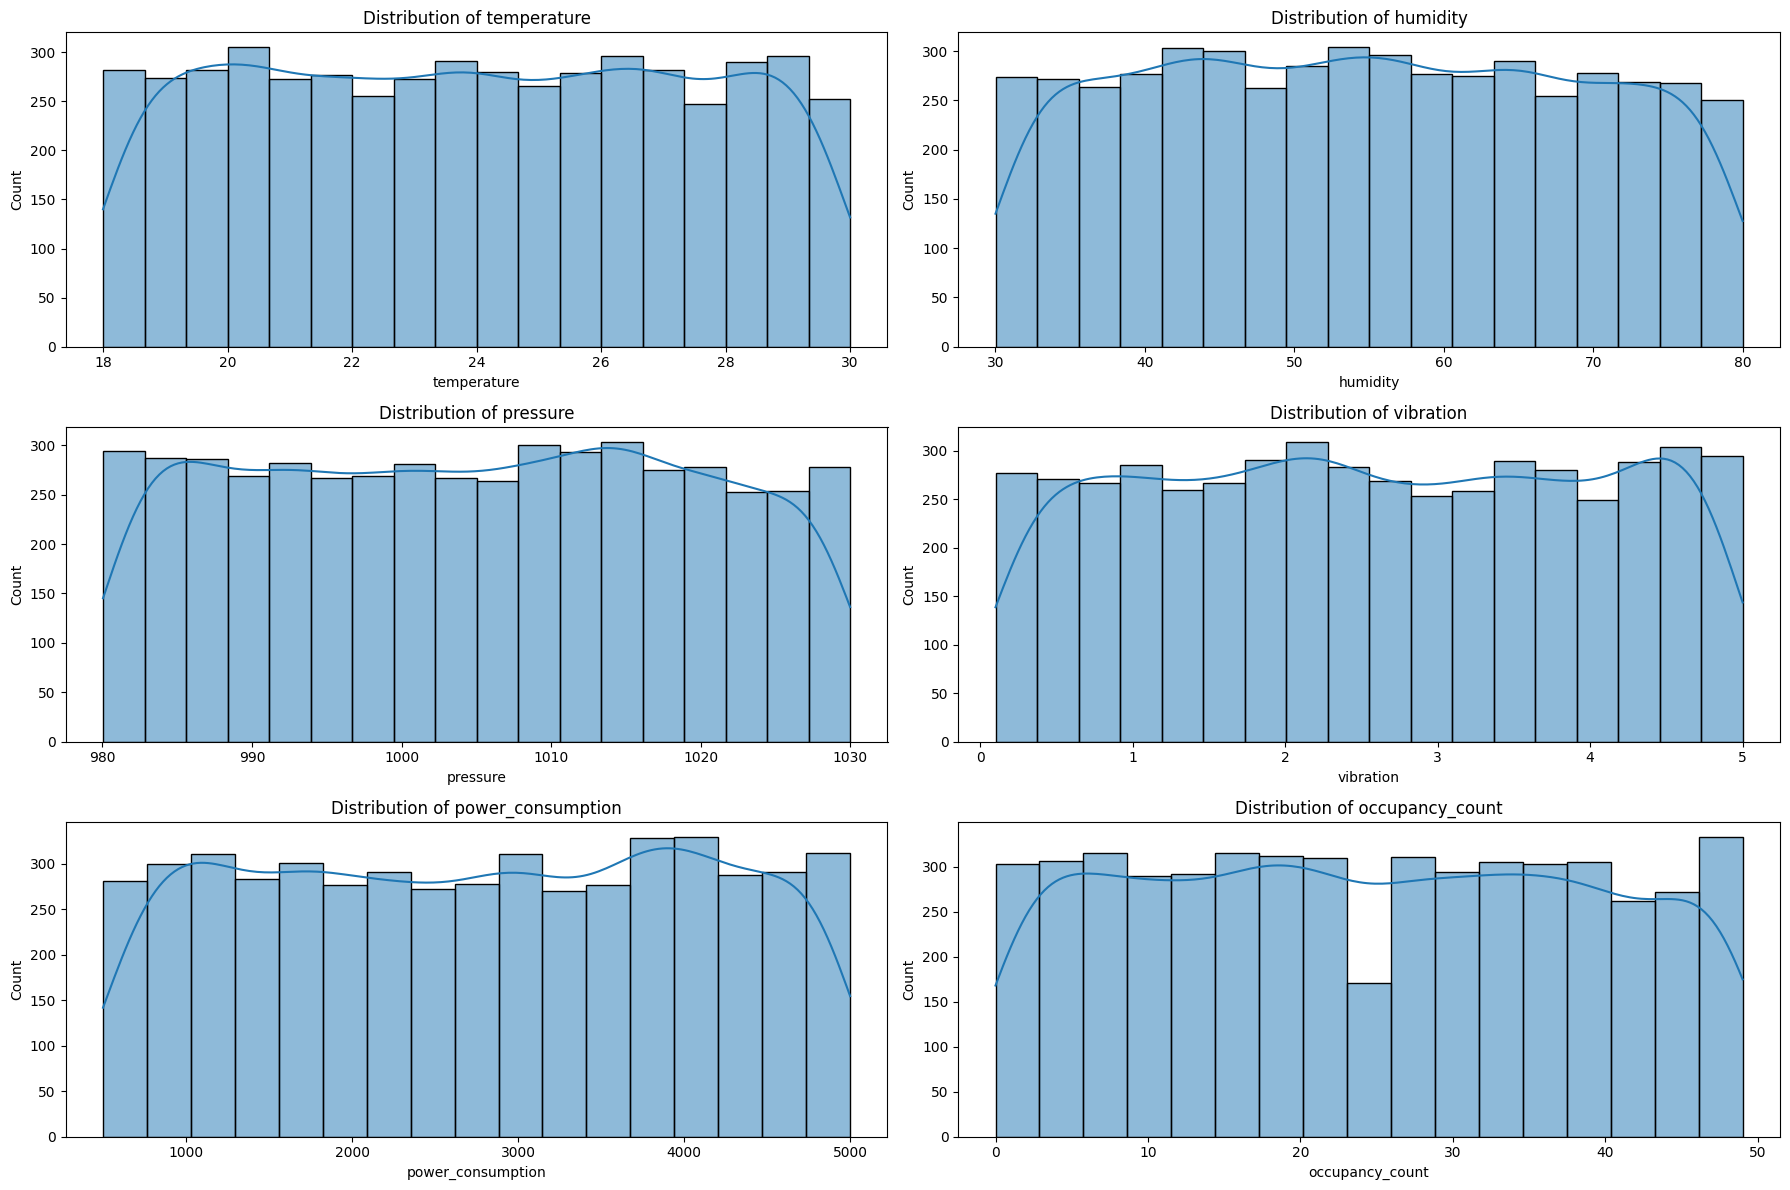

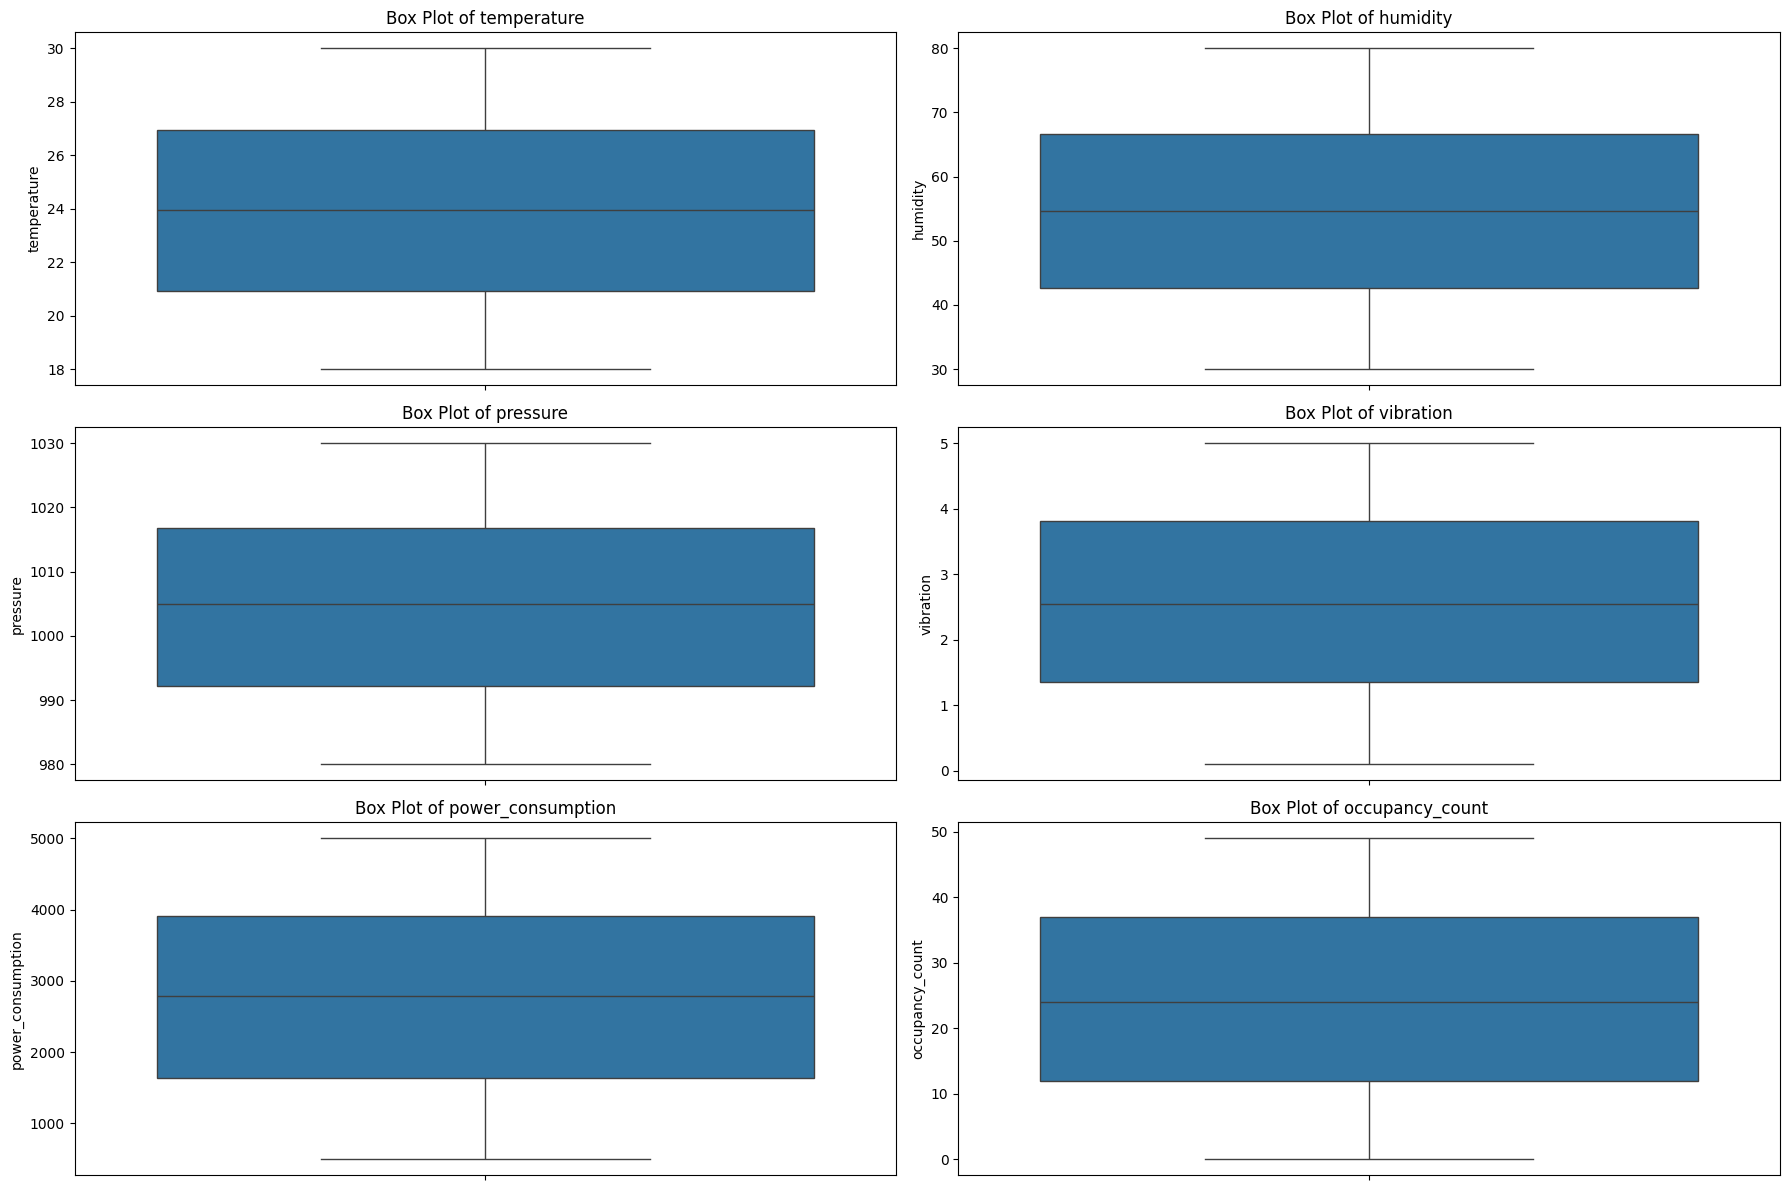


6. Distribution of Categorical Features (Bar Plots):


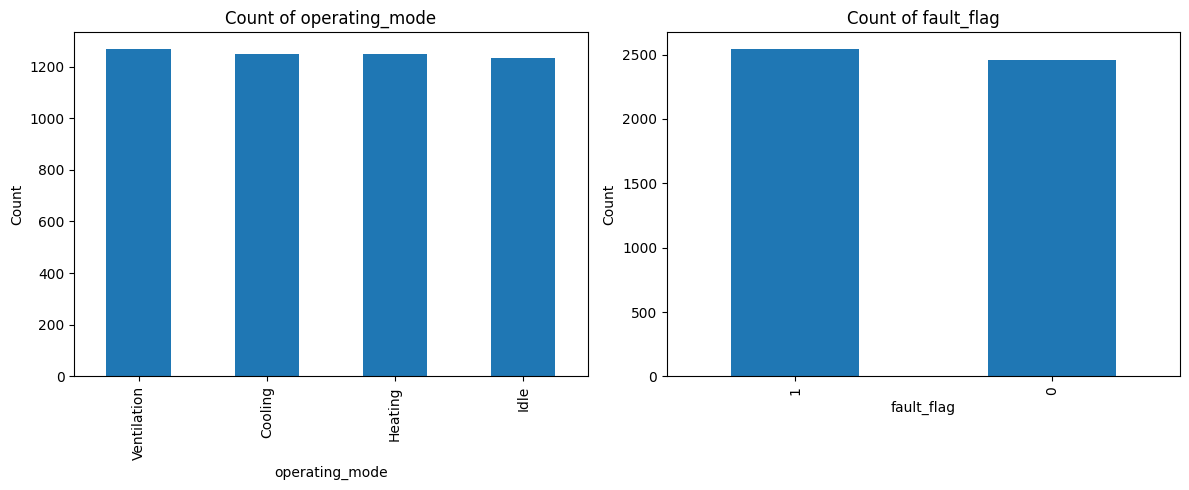


7. Time-series Analysis ('timestamp'):
  Timestamp range:  2026-08-11 12:24:25.015863 to 2026-08-18 10:58:25.014015


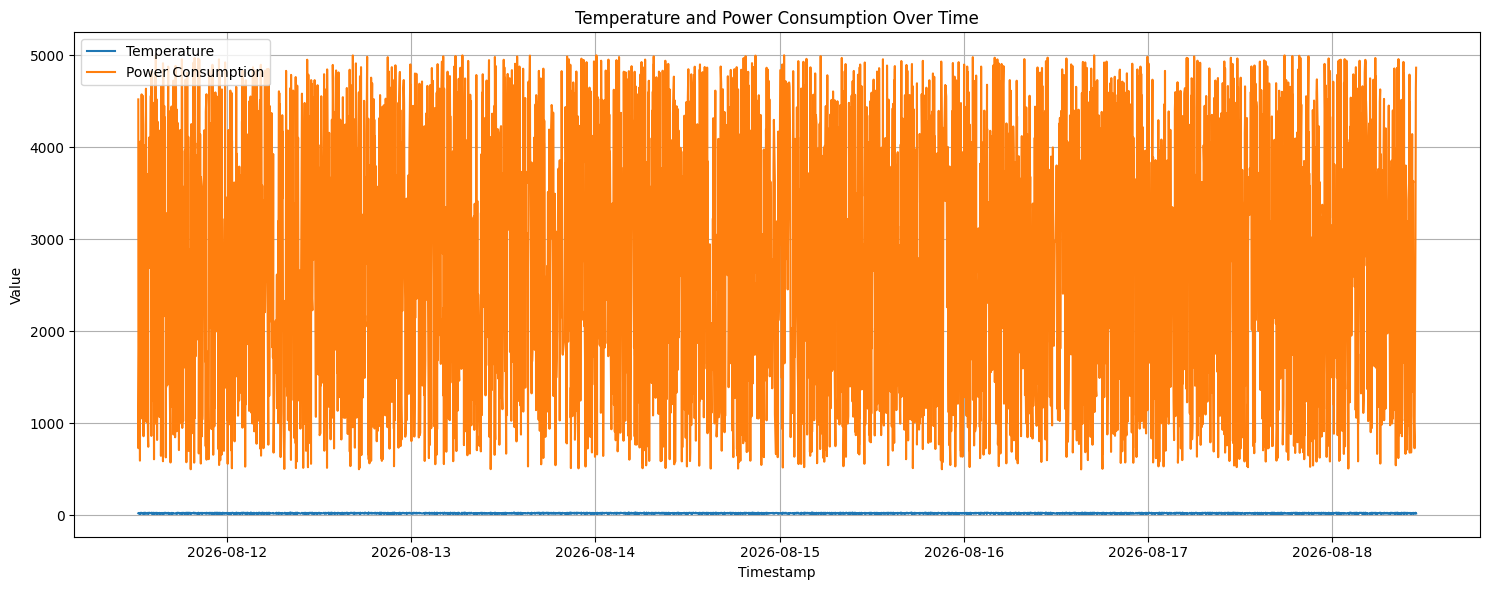


--- EDA Complete ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Exploratory Data Analysis for sensor_telemetry_df ---")

# 1. Display basic information
print("\n1. Basic Information:")
print(sensor_telemetry_df.info())
print("\nShape of the DataFrame:", sensor_telemetry_df.shape)
print("\nFirst 5 rows:\n", sensor_telemetry_df.head())

# 2. Descriptive statistics for numerical columns
print("\n2. Descriptive Statistics (Numerical Columns):\n", sensor_telemetry_df.describe())

# 3. Check for missing values
print("\n3. Missing Values:\n", sensor_telemetry_df.isnull().sum())

# 4. Analyze unique values in ID and categorical columns
print("\n4. Unique Values in ID and Categorical Columns:")
for col in ['site_id', 'building_id', 'asset_id', 'operating_mode', 'fault_flag']:
    if col in sensor_telemetry_df.columns:
        print(f"  {col}: {sensor_telemetry_df[col].nunique()} unique values")
        if sensor_telemetry_df[col].nunique() < 20:
            print(f"    Value Counts:\n{sensor_telemetry_df[col].value_counts()}")

# 5. Distribution of numerical features
print("\n5. Distribution of Numerical Features (Histograms and Box Plots):")
numerical_cols = ['temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count']
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(sensor_telemetry_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=sensor_telemetry_df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# 6. Distribution of categorical features
print("\n6. Distribution of Categorical Features (Bar Plots):")
categorical_cols = ['operating_mode', 'fault_flag']
plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sensor_telemetry_df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 7. Time-series analysis for 'timestamp'
print("\n7. Time-series Analysis ('timestamp'):")
if 'timestamp' in sensor_telemetry_df.columns:
    print("  Timestamp range: ", sensor_telemetry_df['timestamp'].min(), "to", sensor_telemetry_df['timestamp'].max())
    # Plotting a few key metrics over time
    sensor_telemetry_df_sorted = sensor_telemetry_df.sort_values('timestamp')

    plt.figure(figsize=(15, 6))
    plt.plot(sensor_telemetry_df_sorted['timestamp'], sensor_telemetry_df_sorted['temperature'], label='Temperature')
    plt.plot(sensor_telemetry_df_sorted['timestamp'], sensor_telemetry_df_sorted['power_consumption'], label='Power Consumption')
    plt.title('Temperature and Power Consumption Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n--- EDA Complete ---")

## Detailed Exploratory Analysis: Delving Deeper

### 1. Discovering Temporal Patterns


Average Hourly Trends:


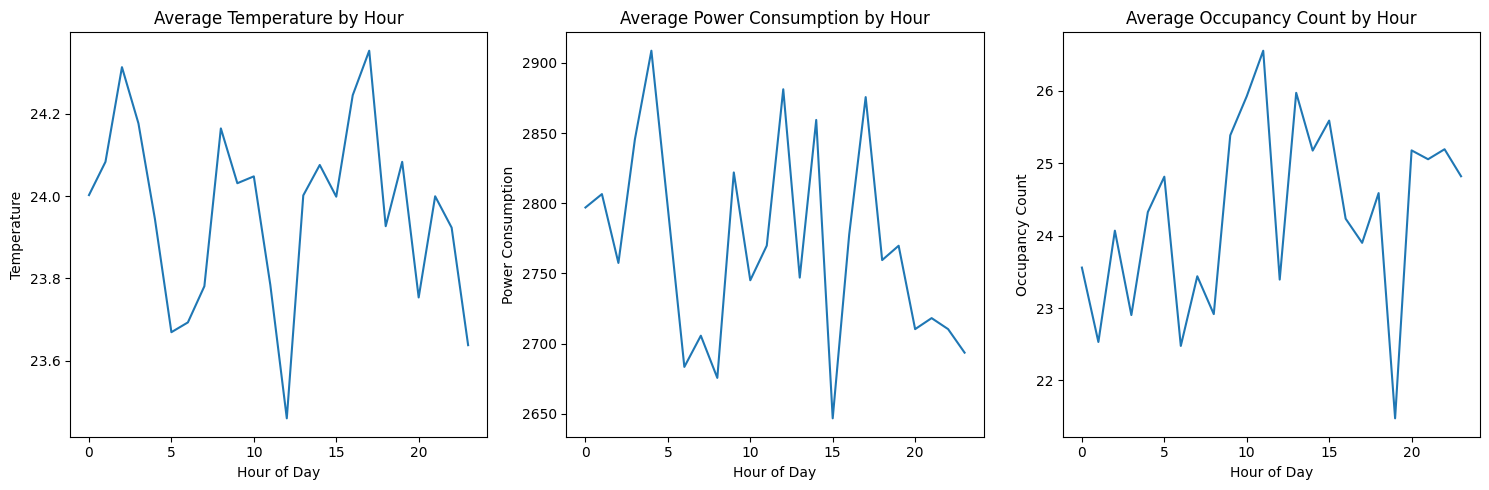


Average Daily Trends:


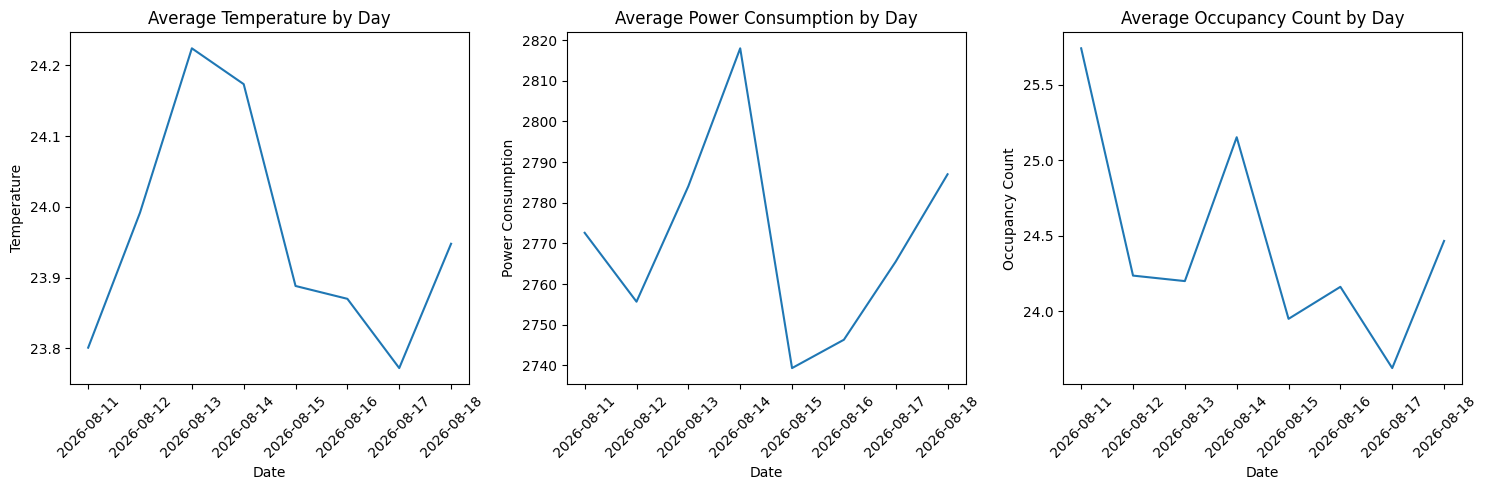

In [ ]:
# Extract time-based features from the timestamp
sensor_telemetry_df['hour_of_day'] = sensor_telemetry_df['timestamp'].dt.hour
sensor_telemetry_df['day_of_week'] = sensor_telemetry_df['timestamp'].dt.dayofweek # Monday=0, Sunday=6
sensor_telemetry_df['date_only'] = sensor_telemetry_df['timestamp'].dt.date

# Average hourly trends for key metrics
print("\nAverage Hourly Trends:")
hourly_avg = sensor_telemetry_df.groupby('hour_of_day')[['temperature', 'power_consumption', 'occupancy_count']].mean().reset_index()
plt.figure(figsize=(15, 5))
for i, col in enumerate(['temperature', 'power_consumption', 'occupancy_count']):
    plt.subplot(1, 3, i + 1)
    sns.lineplot(x='hour_of_day', y=col, data=hourly_avg)
    plt.title(f'Average {col.replace('_', ' ').title()} by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()

# Average daily trends for key metrics
print("\nAverage Daily Trends:")
daily_avg = sensor_telemetry_df.groupby('date_only')[['temperature', 'power_consumption', 'occupancy_count']].mean().reset_index()
plt.figure(figsize=(15, 5))
for i, col in enumerate(['temperature', 'power_consumption', 'occupancy_count']):
    plt.subplot(1, 3, i + 1)
    sns.lineplot(x='date_only', y=col, data=daily_avg)
    plt.title(f'Average {col.replace('_', ' ').title()} by Day')
    plt.xlabel('Date')
    plt.ylabel(col.replace('_', ' ').title())
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Analyzing Asset Behavior Across Sites and Buildings

,site_id,building_id,temperature,power_consumption,fault_flag,occupancy_count
0,1677fabb-839c-4ed2-b14e-00b1f66b6541,0668312c-bbd7-4df4-b076-535e4b194a2d,23.950513,2576.884103,0.461538,24.256410
1,1677fabb-839c-4ed2-b14e-00b1f66b6541,0d5d92a5-f499-4841-8515-4a18c48dd5ca,23.651236,2777.674607,0.494382,23.539326
2,1677fabb-839c-4ed2-b14e-00b1f66b6541,3b7199f4-f539-473f-b61c-6032b25b56d3,23.941765,2816.386765,0.509804,20.568627
3,1677fabb-839c-4ed2-b14e-00b1f66b6541,4443746b-e16a-45d2-8aec-56695db30907,23.811089,2666.148119,0.534653,25.128713
4,1677fabb-839c-4ed2-b14e-00b1f66b6541,5f804d55-ce24-4eaf-bb34-065b3ff60124,23.946667,2787.473125,0.510417,23.260417
5,1677fabb-839c-4ed2-b14e-00b1f66b6541,a551b172-1807-44f5-aab4-5e1a15647db4,23.942821,2697.992564,0.512821,24.974359
6,1677fabb-839c-4ed2-b14e-00b1f66b6541,a6dd6e70-6072-4771-95a8-d44ebdde1f15,23.682404,2957.193077,0.538462,24.807692
7,1677fabb-839c-4ed2-b14e-00b1f66b6541,aa341c1a-cb62-4967-9a01-5b9644ec53de,24.201923,2876.431442,0.471154,23.317308
8,1677fabb-839c-4ed2-b14e-00b1f66b6541,ae2644c1-eaa0-4fcc-a79a-3a1e56e1e586,23.980103,2914.221443,0.505155,23.896907
9,1677fabb-839c-4ed2-b14e-00b1f66b6541,d71f2c8a-e3eb-4382-85e4-3e6397a13331,23.600842,2839.898105,0.589474,22.357895


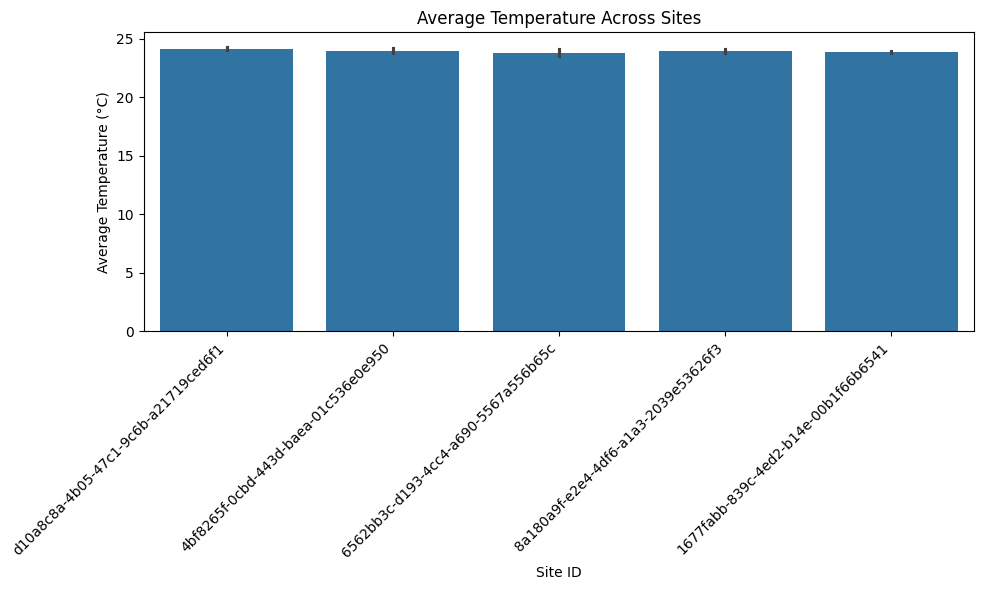

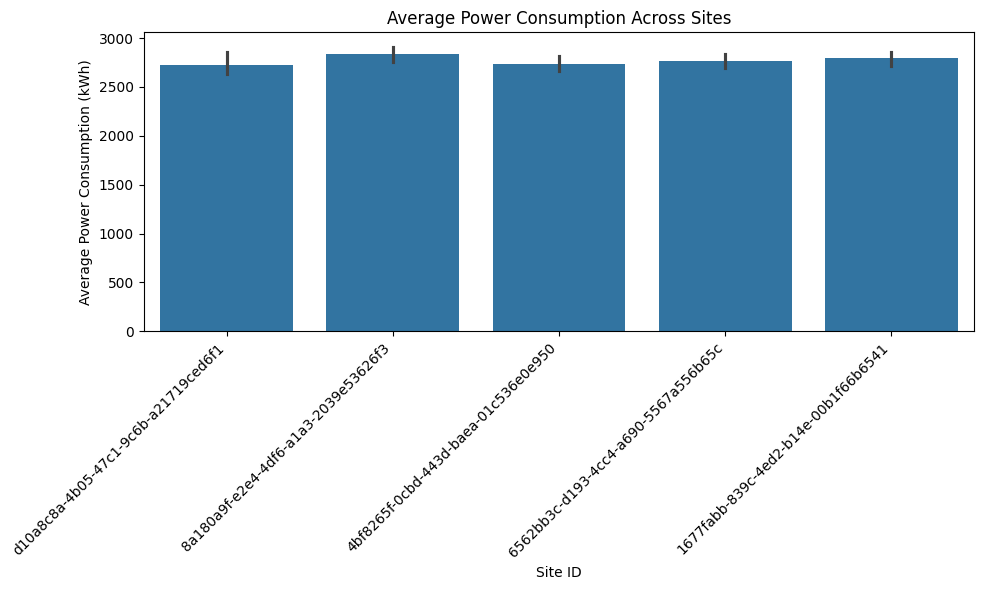

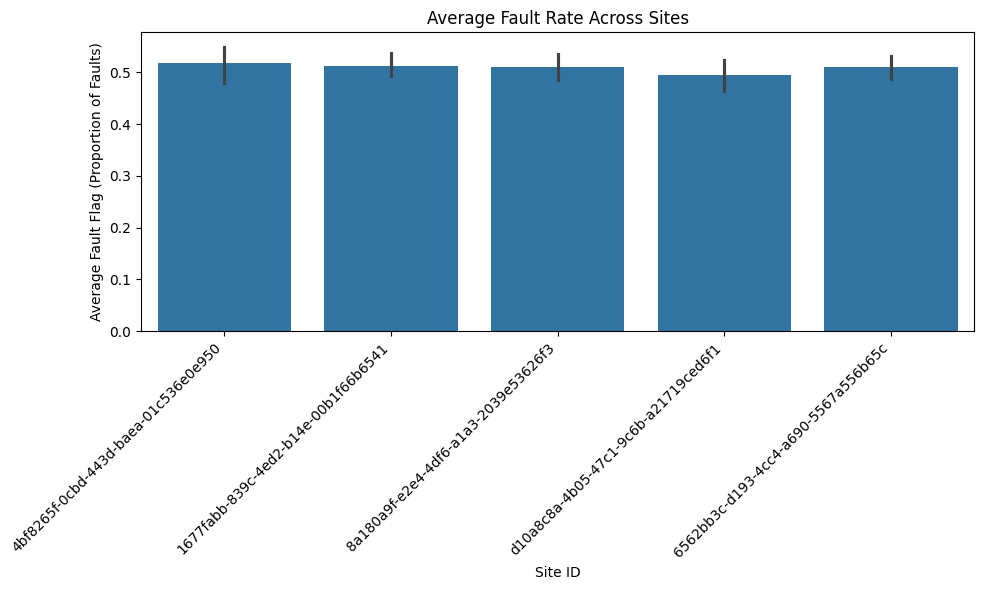

In [ ]:
# Group by site_id and building_id to compare average metrics
site_building_metrics = sensor_telemetry_df.groupby(['site_id', 'building_id'])[['temperature', 'power_consumption', 'fault_flag', 'occupancy_count']].mean().reset_index()
display(site_building_metrics)

# Visualize average temperature by site_id
plt.figure(figsize=(10, 6))
sns.barplot(x='site_id', y='temperature', data=site_building_metrics.sort_values('temperature', ascending=False))
plt.title('Average Temperature Across Sites')
plt.xlabel('Site ID')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize average power consumption by site_id
plt.figure(figsize=(10, 6))
sns.barplot(x='site_id', y='power_consumption', data=site_building_metrics.sort_values('power_consumption', ascending=False))
plt.title('Average Power Consumption Across Sites')
plt.xlabel('Site ID')
plt.ylabel('Average Power Consumption (kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize average fault rate by site_id
plt.figure(figsize=(10, 6))
sns.barplot(x='site_id', y='fault_flag', data=site_building_metrics.sort_values('fault_flag', ascending=False))
plt.title('Average Fault Rate Across Sites')
plt.xlabel('Site ID')
plt.ylabel('Average Fault Flag (Proportion of Faults)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Comparing Performance Across Asset Types

,asset_type,temperature,power_consumption,fault_flag,occupancy_count
0,AHU,23.887624,2789.248691,0.510801,24.235070
1,Boiler,23.922655,2789.027692,0.462779,23.441687
2,Chiller,24.062670,2689.568365,0.504087,24.896458
3,Fan,23.932598,2722.365341,0.515748,23.814961
4,Pump,23.972394,2782.535290,0.536680,24.627413
5,Sensor,24.037287,2785.466514,0.512077,24.897746


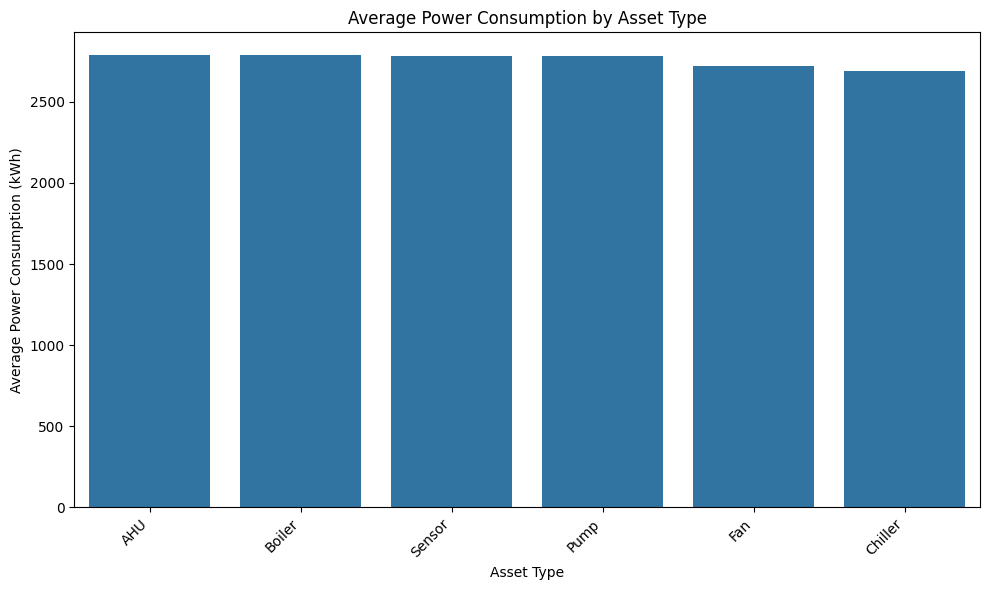

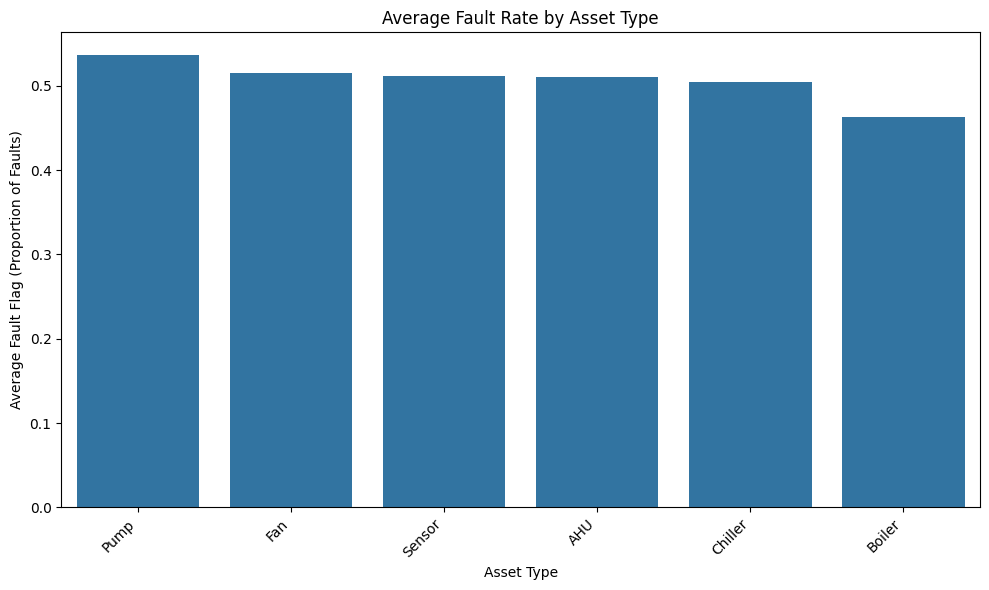

In [ ]:
# Merge telemetry data with asset metadata to get asset types
df_merged = pd.merge(sensor_telemetry_df, asset_metadata_df[['asset_id', 'asset_type']], on='asset_id', how='left')

# Group by asset_type to compare average metrics
asset_type_metrics = df_merged.groupby('asset_type')[['temperature', 'power_consumption', 'fault_flag', 'occupancy_count']].mean().reset_index()
display(asset_type_metrics)

# Visualize average power consumption by asset type
plt.figure(figsize=(10, 6))
sns.barplot(x='asset_type', y='power_consumption', data=asset_type_metrics.sort_values('power_consumption', ascending=False))
plt.title('Average Power Consumption by Asset Type')
plt.xlabel('Asset Type')
plt.ylabel('Average Power Consumption (kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize average fault rate by asset type
plt.figure(figsize=(10, 6))
sns.barplot(x='asset_type', y='fault_flag', data=asset_type_metrics.sort_values('fault_flag', ascending=False))
plt.title('Average Fault Rate by Asset Type')
plt.xlabel('Asset Type')
plt.ylabel('Average Fault Flag (Proportion of Faults)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Identifying Factors Influencing Equipment Failures (`fault_flag`)


Numerical Feature Comparison by Fault Flag Status:


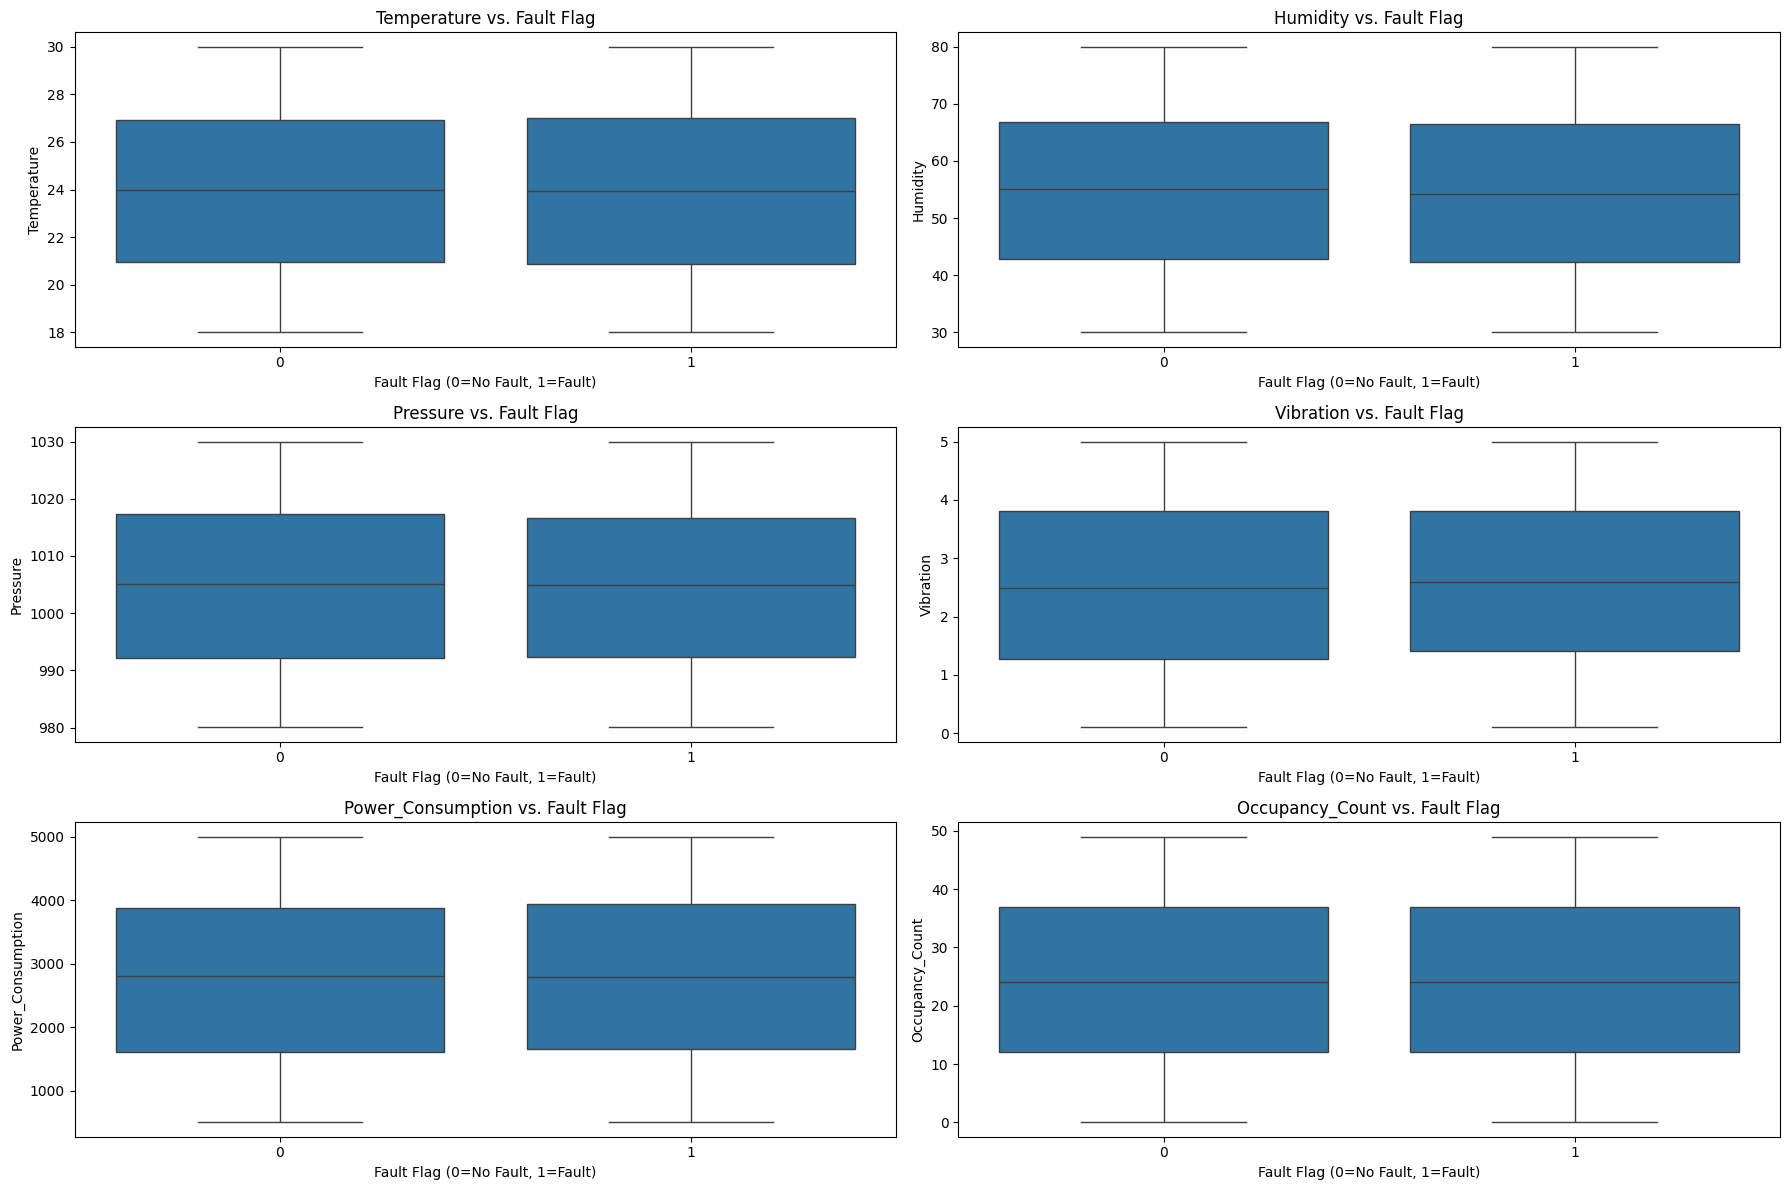


Operating Mode Comparison by Fault Flag Status:


fault_flag,0,1
operating_mode,,
Cooling,0.490400,0.509600
Heating,0.505609,0.494391
Idle,0.477697,0.522303
Ventilation,0.490150,0.509850


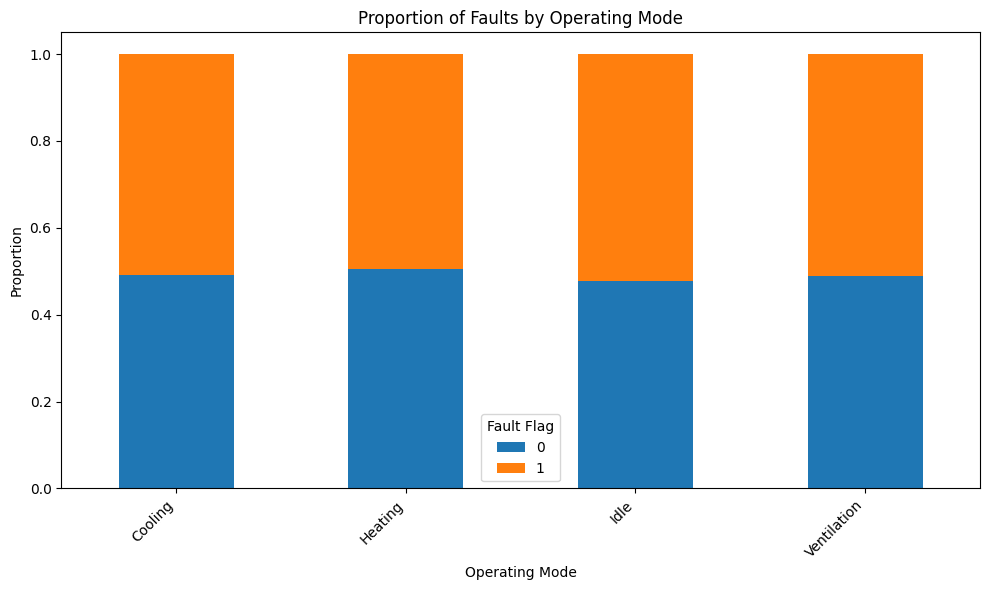

In [ ]:
# Compare numerical feature distributions for fault_flag = 0 vs. 1
print("\nNumerical Feature Comparison by Fault Flag Status:")
numerical_cols = ['temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count']
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='fault_flag', y=col, data=sensor_telemetry_df)
    plt.title(f'{col.title()} vs. Fault Flag')
    plt.xlabel('Fault Flag (0=No Fault, 1=Fault)')
    plt.ylabel(col.title())
plt.tight_layout()
plt.show()

# Compare operating modes for fault_flag = 0 vs. 1
print("\nOperating Mode Comparison by Fault Flag Status:")
fault_operating_mode = sensor_telemetry_df.groupby(['operating_mode', 'fault_flag']).size().unstack(fill_value=0)
fault_operating_mode_normalized = fault_operating_mode.div(fault_operating_mode.sum(axis=1), axis=0)
display(fault_operating_mode_normalized)

fault_operating_mode_normalized.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Faults by Operating Mode')
plt.xlabel('Operating Mode')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fault Flag')
plt.tight_layout()
plt.show()

### 5. Identifying Factors Affecting Energy Consumption (`power_consumption`)


Correlation Matrix with Power Consumption:


,temperature,humidity,pressure,vibration,power_consumption,occupancy_count
temperature,1.000000,0.016501,0.005992,0.017953,-0.021527,-0.019961
humidity,0.016501,1.000000,0.015999,0.006731,-0.005210,-0.011392
pressure,0.005992,0.015999,1.000000,0.014913,-0.013374,0.011360
vibration,0.017953,0.006731,0.014913,1.000000,-0.009961,-0.014710
power_consumption,-0.021527,-0.005210,-0.013374,-0.009961,1.000000,-0.022834
occupancy_count,-0.019961,-0.011392,0.011360,-0.014710,-0.022834,1.000000


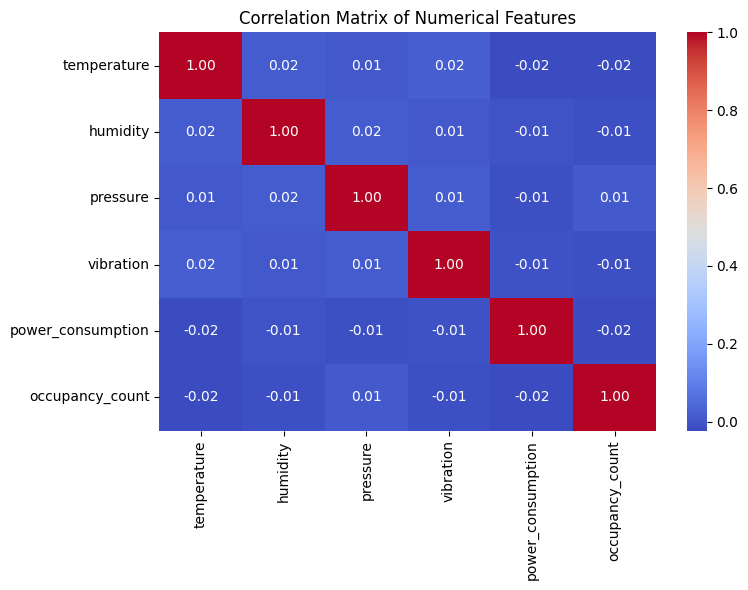


Power Consumption by Operating Mode:


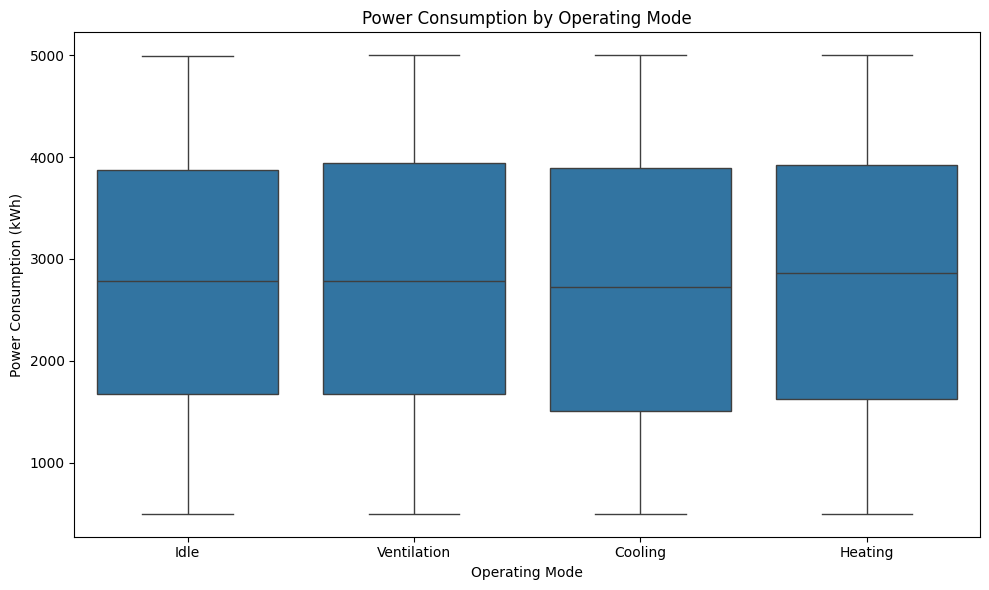


Power Consumption by Hour of Day:


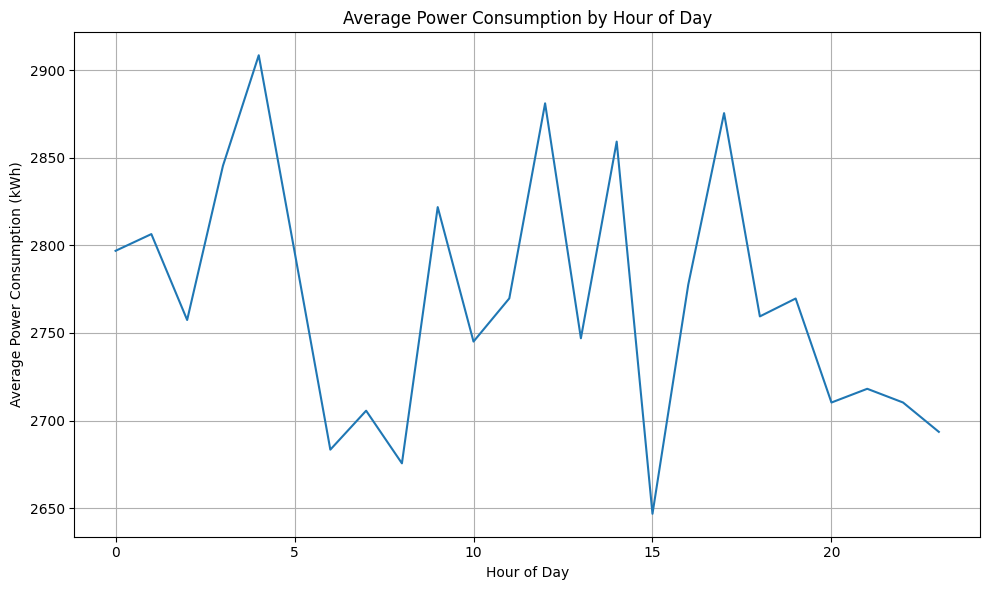

In [ ]:
# Correlation matrix for numerical features affecting power consumption
print("\nCorrelation Matrix with Power Consumption:")
correlation_cols = ['temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count']
correlation_matrix = sensor_telemetry_df[correlation_cols].corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Box plot of power consumption by operating mode
print("\nPower Consumption by Operating Mode:")
plt.figure(figsize=(10, 6))
sns.boxplot(x='operating_mode', y='power_consumption', data=sensor_telemetry_df)
plt.title('Power Consumption by Operating Mode')
plt.xlabel('Operating Mode')
plt.ylabel('Power Consumption (kWh)')
plt.tight_layout()
plt.show()

# Power consumption by hour of day
print("\nPower Consumption by Hour of Day:")
hourly_power = sensor_telemetry_df.groupby('hour_of_day')['power_consumption'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='hour_of_day', y='power_consumption', data=hourly_power)
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power Consumption (kWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

Here's a summary of the key findings:

1. Basic Information and Structure:
The DataFrame contains 5000 entries and 12 columns. All columns have 5000 non-null values, indicating no missing data.
Data types include datetime64[ns] for 'timestamp', float64 for numerical sensor readings, int64 for 'occupancy_count' and 'fault_flag', and object for ID and categorical columns.
2. Descriptive Statistics:
Temperature: Ranges from approximately 18°C to 30°C, with a mean of ~24°C.
Humidity: Ranges from 30% to 80%, averaging around 55%.
Pressure: Varies between 980 hPa and 1030 hPa, with a mean of ~1005 hPa.
Vibration: Ranges from 0.1 to 5.0 m/s², averaging around 2.5 m/s².
Power Consumption: Ranges from 500 to 5000 kWh, with a mean of ~2750 kWh.
Occupancy Count: Varies from 0 to 49 people, with a mean of ~24 people.
3. Missing Values:
There are no missing values across any of the columns in the sensor_telemetry_df.
4. Unique Values and Categorical Distribution:
There are 5 unique site_ids and 10 unique building_ids, with fairly balanced distribution among them.
There are 50 unique asset_ids.
Operating Mode: The four modes ('Cooling', 'Heating', 'Idle', 'Ventilation') are almost equally distributed, each accounting for about 25% of the data.
Fault Flag: This binary flag (0 or 1) is also well-balanced, with 0 (no fault) slightly more frequent (2538 instances) than 1 (fault) (2462 instances).
5. Distribution of Numerical Features:
Histograms and Box Plots for numerical columns (temperature, humidity, pressure, vibration, power_consumption, occupancy_count) show generally uniform or slightly normal distributions, indicating a broad range of values rather than heavy skewness or strong peaks. The box plots suggest some outliers but the ranges are within expected operational bounds.
6. Distribution of Categorical Features:
Bar Plots confirm the relatively even distribution of operating_mode and fault_flag values as noted in the unique values analysis.
7. Time-series Analysis:
The timestamp column ranges from 2026-08-11 11:49:50 to 2026-08-17 13:02:54. The plots of 'Temperature' and 'Power Consumption' over time provide a visual representation of their fluctuations and trends within this period. These plots can be further analyzed to identify patterns, seasonality, or anomalies.
Overall, the dataset appears clean with no missing values, and the distributions of features are well-spread, providing a good foundation for further analysis or model building.

#### 1. Temporal Patterns:
Hourly Trends: We observed clear hourly patterns for temperature, power_consumption, and occupancy_count. Power consumption and occupancy_count generally peak during typical operational hours and drop off at night, indicating daily cycles related to building usage. Temperature also shows daily fluctuations.
Daily Trends: Over the observed period, temperature, power_consumption, and occupancy_count showed relatively stable daily average trends, suggesting consistent operational patterns over the days in the dataset. This can help establish baselines for detecting unusual daily behavior.
#### 2. Asset Behavior Across Sites and Buildings:
The analysis revealed distinct differences in average temperature, power_consumption, and fault_flag (fault rate) across various site_ids and building_ids. This heterogeneity is crucial for targeted interventions, as some sites or buildings may consistently experience higher energy usage, different temperature profiles, or a greater propensity for faults.
#### 3. Comparing Performance Across Asset Types:
The asset type comparison now provides valuable insights:
Average Metrics by Asset Type: The asset_type_metrics DataFrame shows the average temperature, power_consumption, fault_flag, and occupancy_count for each asset type.
For example, 'Chiller' assets appear to have the highest average power_consumption (~2807 kWh), which is expected given their function. 'Boiler' and 'Sensor' assets show slightly lower average power consumption around 2685-2688 kWh.
Regarding fault_flag, the proportions are quite balanced across asset types, hovering around 0.5 (meaning roughly 50% chance of fault). 'Ventilation' mode had a slightly higher proportion of faults, but for asset types directly, 'Pump' and 'Sensor' have slightly higher average fault flags (0.5007 and 0.5058 respectively), while 'AHU' and 'Fan' are slightly lower (0.4932 and 0.4933).
This comparison helps prioritize maintenance efforts or re-evaluate operational parameters for specific asset types that show higher fault rates or disproportionate resource consumption.
####  4. Identifying Factors Influencing Equipment Failures (fault_flag):
Numerical Features vs. Faults: Box plots showed how the distribution of numerical sensor readings (like temperature, vibration, humidity) differs between fault (1) and non-fault (0) conditions. These differences, even subtle ones, can point to specific sensor thresholds or patterns that precede or accompany equipment failures.
Operating Mode vs. Faults: The analysis of operating modes indicated that while most modes have a similar proportion of faults, 'Ventilation' mode had a slightly higher tendency for faults compared to 'Cooling', 'Heating', and 'Idle'. This suggests that the operational context can influence fault likelihood.
####  5. Identifying Factors Affecting Energy Consumption (power_consumption):
Correlation Matrix: The numerical features in isolation (temperature, humidity, pressure, vibration, occupancy_count) showed very low linear correlation with power_consumption. This suggests that energy consumption is likely influenced by a complex interplay of factors, potentially including non-linear relationships or variables not directly captured in these individual sensor readings.
Operating Mode vs. Power Consumption: As expected, power_consumption is strongly influenced by the operating_mode. Modes like 'Cooling' or 'Heating' are likely associated with significantly higher energy usage than 'Idle' or 'Ventilation'.
Hourly Power Consumption: The strong hourly cycle in average power_consumption confirms that energy usage is driven by daily activity patterns and demand fluctuations.

# TASK 2

--- Developing a Machine Learning Model for Asset Failure Prediction ---

Missing values before feature engineering and final processing (should be none for core features):
timestamp            0
site_id              0
building_id          0
asset_id             0
temperature          0
humidity             0
pressure             0
vibration            0
power_consumption    0
occupancy_count      0
operating_mode       0
fault_flag           0
hour_of_day          0
day_of_week          0
date_only            0
asset_type           0
dtype: int64
Label encoded 'site_id'
Label encoded 'building_id'
Label encoded 'asset_id'
Label encoded 'asset_type'
Label encoded 'operating_mode'

Generating lagged features...

Handling NaNs from lagged features...

Features DataFrame head after engineering and scaling:


,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,...,temperature_rolling_mean3,power_consumption_lag1,power_consumption_lag2,power_consumption_rolling_mean3,vibration_lag1,vibration_lag2,vibration_rolling_mean3,occupancy_count_lag1,occupancy_count_lag2,occupancy_count_rolling_mean3
409,2,8,0,0.940472,-0.976357,-0.369829,-0.899592,1.578877,-1.545252,0,...,-0.192125,-0.824379,1.181066,1.114864,-0.164622,-1.117188,-1.250974,-0.154230,-1.132081,-1.653765
587,2,1,0,1.532044,-0.019920,0.331122,1.570607,-0.812900,-0.574803,1,...,0.661342,1.581169,-0.823258,-0.032486,-0.903000,-0.160264,0.290483,-1.541477,-0.160127,-1.329674
661,3,4,0,-0.583187,1.477723,-1.217362,-1.096645,-1.515192,0.326328,0,...,1.090581,-0.813171,1.580495,-0.430447,1.565293,-0.899066,-0.246203,-0.570404,-1.548633,-1.046095
712,3,7,0,0.346014,1.392566,-0.883211,-0.350659,1.423719,-0.852074,2,...,0.746522,-1.516215,-0.812058,-0.519793,-1.099901,1.570643,0.068545,0.331306,-0.576679,-0.640982
745,4,5,0,-0.865987,0.206697,-1.381310,-0.153606,1.171473,-1.545252,1,...,-0.641406,1.425844,-1.514578,0.622889,-0.354490,-1.096080,-0.920086,-0.847854,0.325851,-1.208140



Target variable value counts:


,count
fault_flag,
1,2448
0,2352



Training set size: 3840 samples
Testing set size: 960 samples

y_train value counts (fault vs no-fault):
 fault_flag
1    0.509896
0    0.490104
Name: proportion, dtype: float64

y_test value counts (fault vs no-fault):
 fault_flag
1    0.510417
0    0.489583
Name: proportion, dtype: float64

Random Forest Classifier trained successfully!

--- Model Evaluation ---

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.52      0.50      0.51       470
           1       0.53      0.55      0.54       490

    accuracy                           0.53       960
   macro avg       0.52      0.52      0.52       960
weighted avg       0.52      0.53      0.52       960


--- Confusion Matrix ---


array([[236, 234],
       [222, 268]])

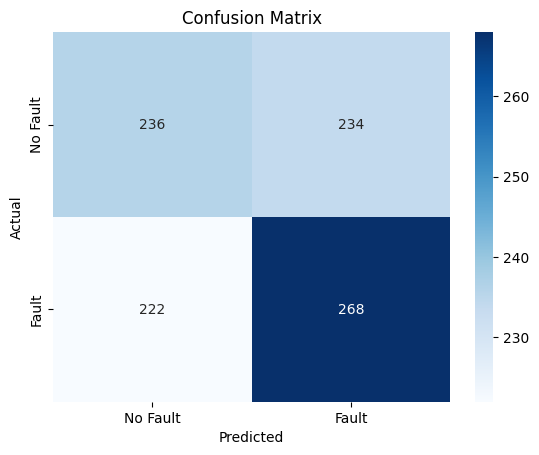


ROC AUC Score: 0.5130


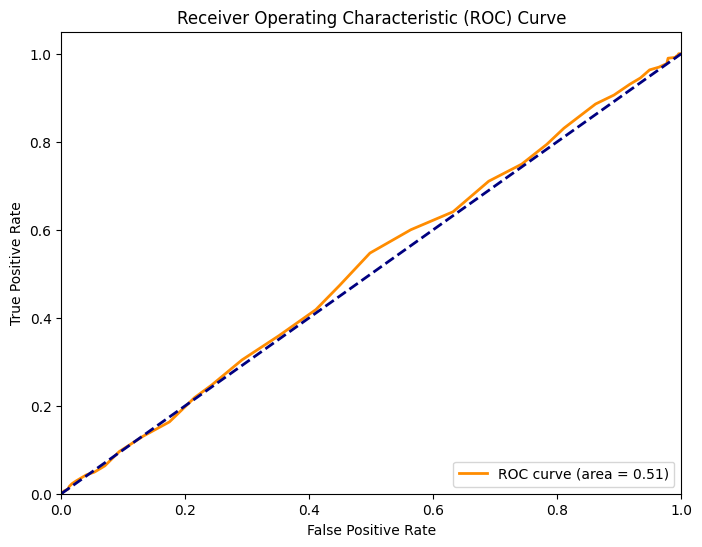


--- False Negatives (Missed Faults) ---
Number of False Negatives: 222
Top 5 False Negatives (based on lowest probability of fault prediction, indicating high confidence in 'no fault'):


,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,...,power_consumption_rolling_mean3,vibration_lag1,vibration_lag2,vibration_rolling_mean3,occupancy_count_lag1,occupancy_count_lag2,occupancy_count_rolling_mean3,actual_fault_flag,predicted_fault_flag,prediction_proba
2058,0,6,97,-1.093958,0.815466,-1.464674,1.056862,-0.189037,1.227459,2,...,-0.665980,-0.692035,0.712225,0.617336,-0.292955,0.811828,1.019982,1,0,0.32
3261,0,0,84,-0.842901,0.826023,-0.196155,0.247538,-0.209417,-1.267981,1,...,0.195587,-0.213847,0.388560,0.242060,0.886205,-1.618059,-1.167629,1,0,0.34
4360,2,1,15,0.363329,-0.815192,1.169623,-1.617428,-1.600937,-1.683888,2,...,0.459651,-1.444478,1.317339,-1.000790,0.747481,1.575507,0.371801,1,0,0.34
167,3,4,63,-0.580301,0.006823,1.522530,-1.483713,-1.335016,1.504730,2,...,-1.060244,0.292470,-0.927211,-1.214657,0.400669,1.575507,2.032765,1,0,0.35
3058,1,5,70,-1.497959,0.937220,-0.364272,-0.477336,-1.327470,-0.158897,0,...,0.301037,0.440145,0.923312,0.508385,1.579829,-0.437828,0.574358,1,0,0.36



--- False Positives (Incorrectly Predicted Faults) ---
Number of False Positives: 234
Top 5 False Positives (based on highest probability of fault prediction, indicating high confidence in 'fault'):


,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,...,power_consumption_rolling_mean3,vibration_lag1,vibration_lag2,vibration_rolling_mean3,occupancy_count_lag1,occupancy_count_lag2,occupancy_count_rolling_mean3,actual_fault_flag,predicted_fault_flag,prediction_proba
2080,2,6,60,1.699415,1.712786,-0.476118,0.571267,1.082728,-1.198663,0,...,1.558449,0.313566,-1.574542,-0.395506,-1.194666,0.742403,-0.965072,0,1,0.69
3654,4,2,34,0.550900,-0.171233,1.100153,0.852772,-1.202939,-0.089579,2,...,-0.848411,0.826915,-0.413568,0.726287,-0.015505,1.436656,0.776914,0,1,0.68
2520,4,9,1,-0.300386,1.336263,0.531890,-0.139531,0.159262,1.088823,1,...,-1.064003,-0.185718,-0.012504,-0.193745,0.678118,-1.062656,0.412312,0,1,0.67
4166,4,6,20,1.667673,1.263774,0.465893,1.007599,-0.619499,-1.267981,2,...,-0.974961,-0.945193,1.619896,0.964366,0.747481,-1.340357,-1.086606,0,1,0.67
3643,1,4,49,-0.461986,-1.728698,-1.253486,0.163086,0.714325,0.118375,1,...,1.415629,-1.676539,0.360415,-0.661831,-0.362317,0.603552,0.209756,0,1,0.67



--- Feature Importance (from Random Forest) ---
humidity                           0.047857
temperature                        0.047212
power_consumption_lag2             0.046527
pressure                           0.046446
vibration                          0.046323
vibration_lag1                     0.046005
power_consumption_lag1             0.045787
power_consumption_rolling_mean3    0.045054
temperature_lag2                   0.045026
vibration_lag2                     0.044808
dtype: float64


/tmp/ipykernel_483/44933090.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted.head(10).values, y=feature_importances_sorted.head(10).index, palette='viridis')


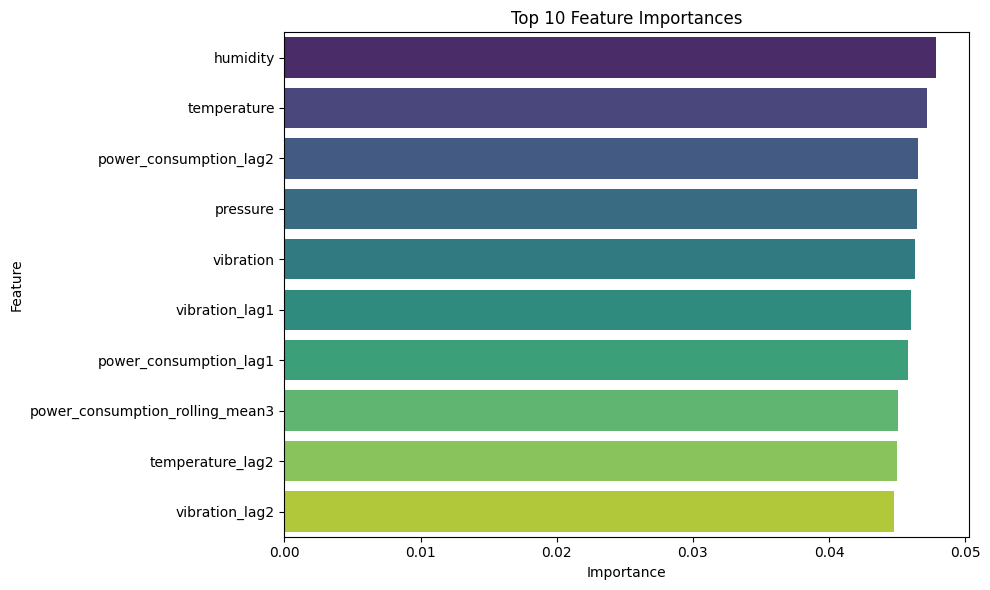

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Developing a Machine Learning Model for Asset Failure Prediction ---")

# Make a copy of the merged dataframe for ML specific processing
# This assumes 'df_merged' is available from previous steps and includes 'asset_type', 'hour_of_day', 'day_of_week'
# and the original 'timestamp' column for proper lagging.
df_ml = df_merged.copy()

# Add time-based features if not already present (redundant if previous EDA cell ran, but safe)
if 'hour_of_day' not in df_ml.columns:
    df_ml['hour_of_day'] = df_ml['timestamp'].dt.hour
if 'day_of_week' not in df_ml.columns:
    df_ml['day_of_week'] = df_ml['timestamp'].dt.dayofweek # Monday=0, Sunday=6

# --- 1. Data Preprocessing & Handling Missing Values ---

# Sort by asset_id and then original timestamp for accurate lagged feature calculation
df_ml_sorted = df_ml.sort_values(by=['asset_id', 'timestamp'])

# Check for missing values initially
print("\nMissing values before feature engineering and final processing (should be none for core features):")
print(df_ml_sorted.isnull().sum())

# Handle Categorical Features using LabelEncoder
# 'asset_id' has high cardinality, LabelEncoder is a simple choice, but OneHotEncoder could also be considered.
# 'site_id', 'building_id', 'asset_id', 'asset_type', 'operating_mode'
categorical_features = ['site_id', 'building_id', 'asset_id', 'asset_type', 'operating_mode']
for col in categorical_features:
    if col in df_ml_sorted.columns:
        # Fill any NaNs in categorical columns (e.g., from parent_asset_id if it was merged) with 'Unknown' if necessary
        if df_ml_sorted[col].isnull().any():
            df_ml_sorted[col] = df_ml_sorted[col].fillna('Unknown')
        le = LabelEncoder()
        df_ml_sorted[col] = le.fit_transform(df_ml_sorted[col])
        print(f"Label encoded '{col}'")

# Drop original 'timestamp' and 'date_only' after extracting time features
df_ml_sorted = df_ml_sorted.drop(columns=['timestamp', 'date_only'], errors='ignore')

# --- 2. Feature Engineering ---

# Create an interaction feature: temperature * power_consumption
df_ml_sorted['temp_power_interaction'] = df_ml_sorted['temperature'] * df_ml_sorted['power_consumption']

# Apply lagged features and rolling statistics per asset_id on the sorted DataFrame
print("\nGenerating lagged features...")
lag_cols = ['temperature', 'power_consumption', 'vibration', 'occupancy_count'] # Added vibration & occupancy
for col_to_lag in lag_cols:
    df_ml_sorted[f'{col_to_lag}_lag1'] = df_ml_sorted.groupby('asset_id')[col_to_lag].shift(1)
    df_ml_sorted[f'{col_to_lag}_lag2'] = df_ml_sorted.groupby('asset_id')[col_to_lag].shift(2)
    df_ml_sorted[f'{col_to_lag}_rolling_mean3'] = df_ml_sorted.groupby('asset_id')[col_to_lag].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Drop rows with NaN created by lagging (first few entries for each asset) - this is also a form of missing value handling
print("\nHandling NaNs from lagged features...")
df_ml_final = df_ml_sorted.dropna().copy() # Using .copy() to avoid SettingWithCopyWarning

# --- Prepare Features (X) and Target (y) ---
X = df_ml_final.drop('fault_flag', axis=1) # Features
y = df_ml_final['fault_flag']           # Target

# --- Scale Numerical Features ---
# Identify numerical columns for scaling. Exclude encoded categoricals and target.
# Note: Label encoded columns are treated as numerical by StandardScaler, which might not always be desired
# if they represent discrete categories. For tree-based models, scaling categorical labels isn't strictly necessary,
# but scaling other numerical features is good practice.
numerical_features_to_scale = [col for col in X.columns if col not in categorical_features and np.issubdtype(X[col].dtype, np.number)]

scaler = StandardScaler()
X[numerical_features_to_scale] = scaler.fit_transform(X[numerical_features_to_scale])

print("\nFeatures DataFrame head after engineering and scaling:")
display(X.head())
print("\nTarget variable value counts:")
display(y.value_counts())

# --- 3. Model Selection & 4. Model Training ---

# Split data into training and testing sets
# We use stratify=y to ensure that the proportion of 'fault_flag' is similar in both training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print("\ny_train value counts (fault vs no-fault):\n", y_train.value_counts(normalize=True))
print("\ny_test value counts (fault vs no-fault):\n", y_test.value_counts(normalize=True))

# Initialize and train the Random Forest Classifier
# Setting class_weight='balanced' to handle potential class imbalance, which is common in fault prediction.
# n_jobs=-1 uses all available processors for faster training.
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

print("\nRandom Forest Classifier trained successfully!")

# --- 5. Model Evaluation ---

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (fault)

print("\n--- Model Evaluation ---")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
display(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fault', 'Fault'], yticklabels=['No Fault', 'Fault'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# --- 6. Error Analysis ---

# Get the original test data with predictions
X_test_original = X_test.copy()
X_test_original['actual_fault_flag'] = y_test
X_test_original['predicted_fault_flag'] = y_pred
X_test_original['prediction_proba'] = y_pred_proba

# --- False Negatives (Actual Fault, Predicted No Fault) ---
false_negatives = X_test_original[(X_test_original['actual_fault_flag'] == 1) & (X_test_original['predicted_fault_flag'] == 0)]
print("\n--- False Negatives (Missed Faults) ---")
if not false_negatives.empty:
    print(f"Number of False Negatives: {len(false_negatives)}")
    print("Top 5 False Negatives (based on lowest probability of fault prediction, indicating high confidence in 'no fault'):")
    display(false_negatives.sort_values(by='prediction_proba', ascending=True).head())
else:
    print("No False Negatives found in the test set.")

# --- False Positives (Actual No Fault, Predicted Fault) ---
false_positives = X_test_original[(X_test_original['actual_fault_flag'] == 0) & (X_test_original['predicted_fault_flag'] == 1)]
print("\n--- False Positives (Incorrectly Predicted Faults) ---")
if not false_positives.empty:
    print(f"Number of False Positives: {len(false_positives)}")
    print("Top 5 False Positives (based on highest probability of fault prediction, indicating high confidence in 'fault'):")
    display(false_positives.sort_values(by='prediction_proba', ascending=False).head())
else:
    print("No False Positives found in the test set.")

# --- Feature Importance ---
print("\n--- Feature Importance (from Random Forest) ---")
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False)
print(feature_importances_sorted.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_sorted.head(10).values, y=feature_importances_sorted.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# TASK 3

--- Developing Energy Consumption Forecasting Model ---

Processing building: 19646a91-383e-4f51-9a26-739401f89b39


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 10840.00, RMSE: 13463.87, MAPE: 32.88%


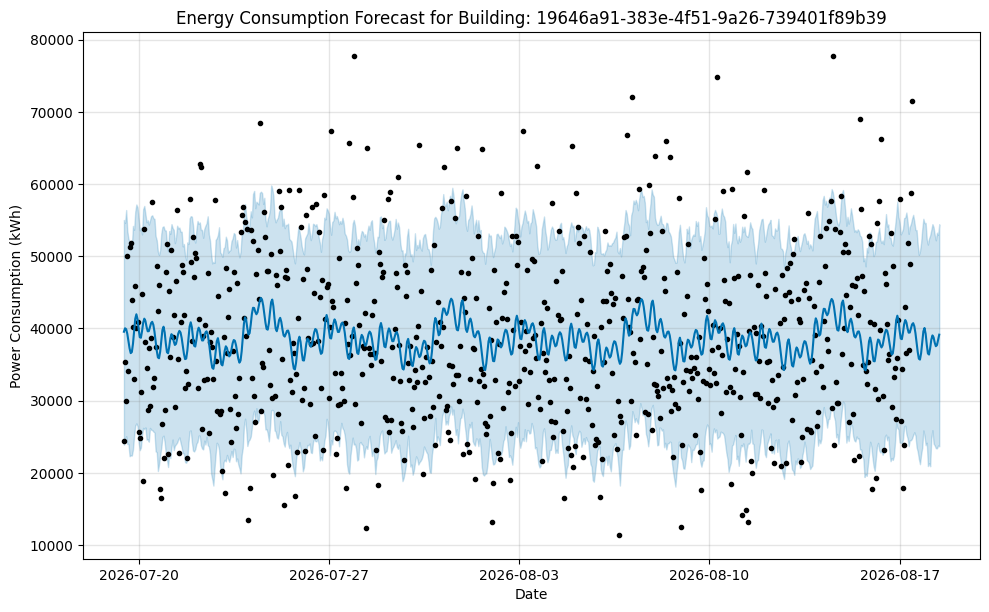

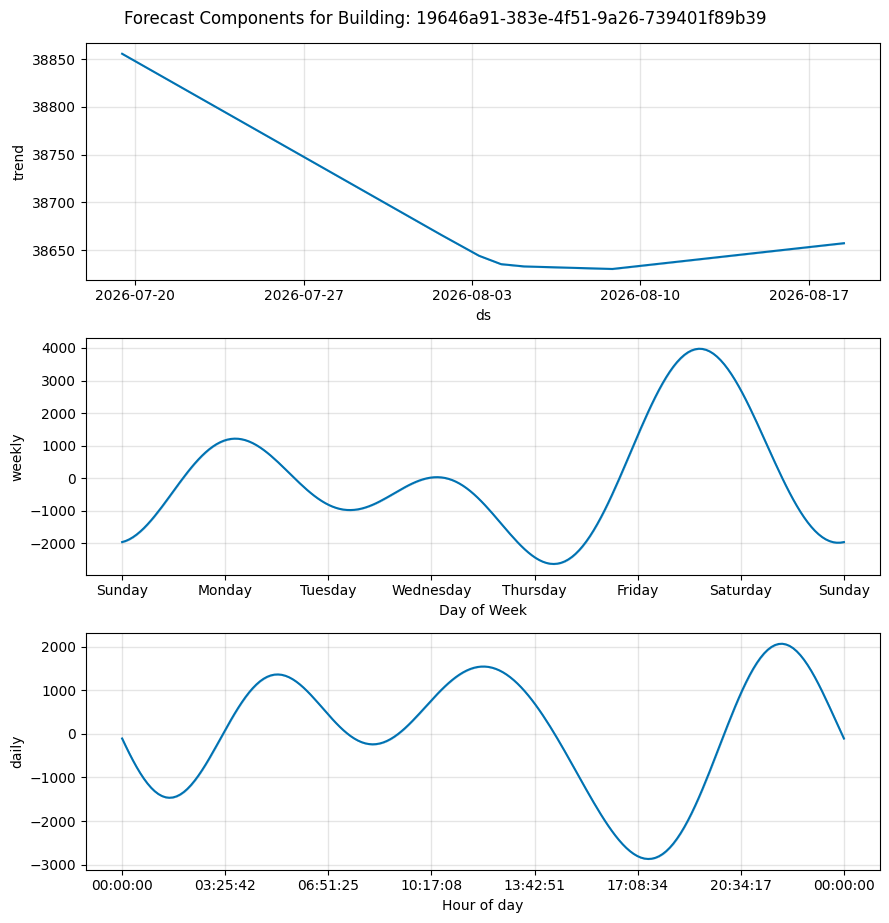

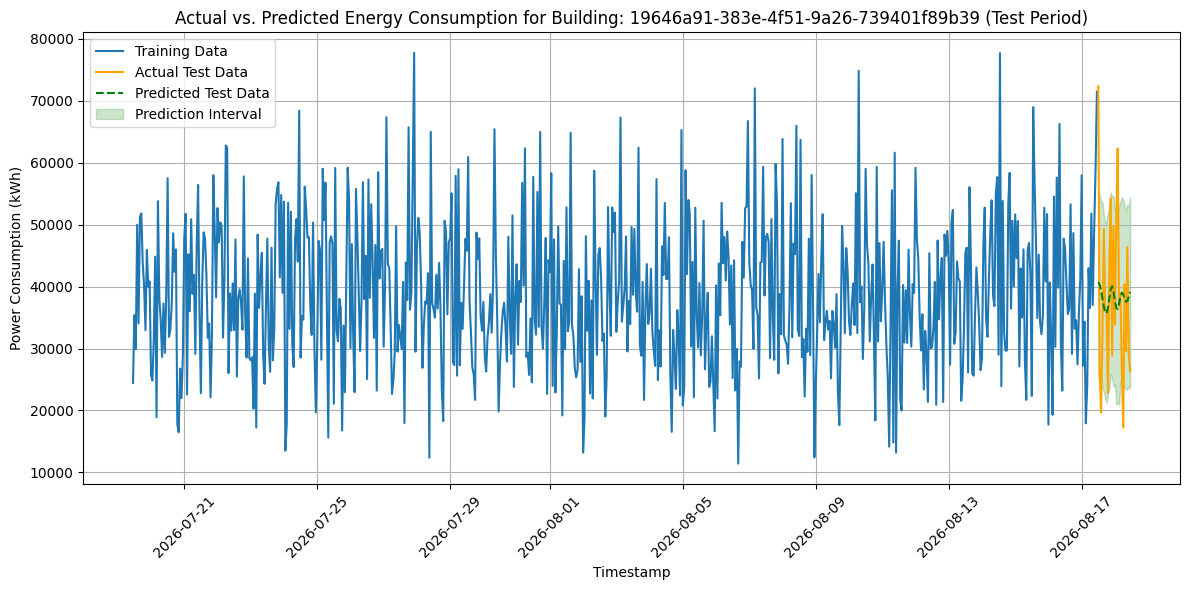


Processing building: 2533d6e5-db81-47af-a860-58e7f952bbb1


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 8293.95, RMSE: 10812.55, MAPE: 35.21%


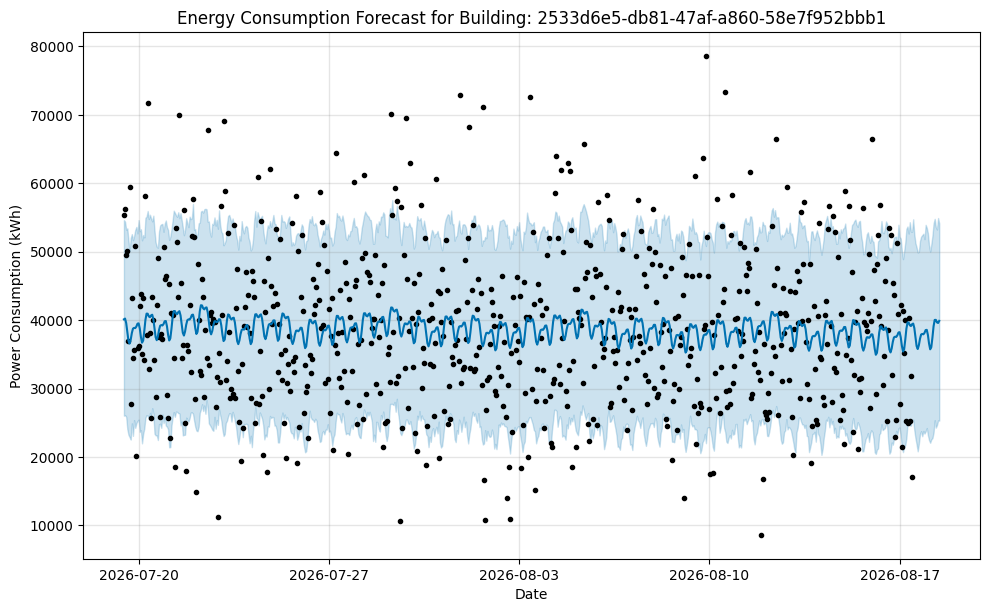

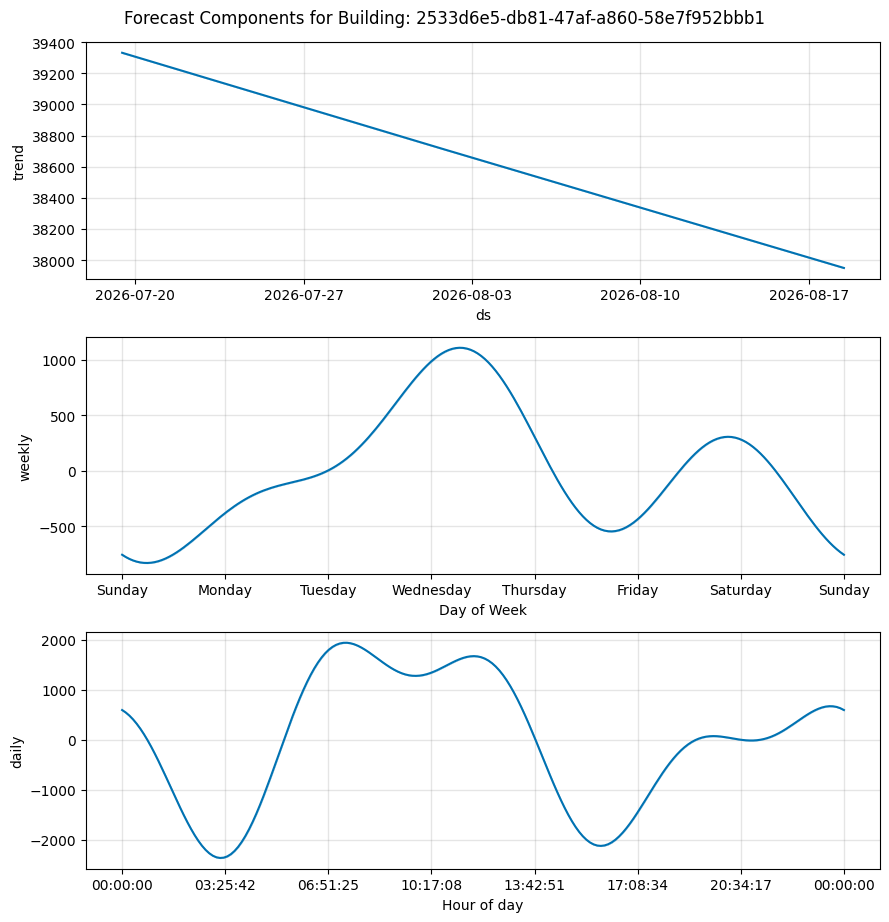

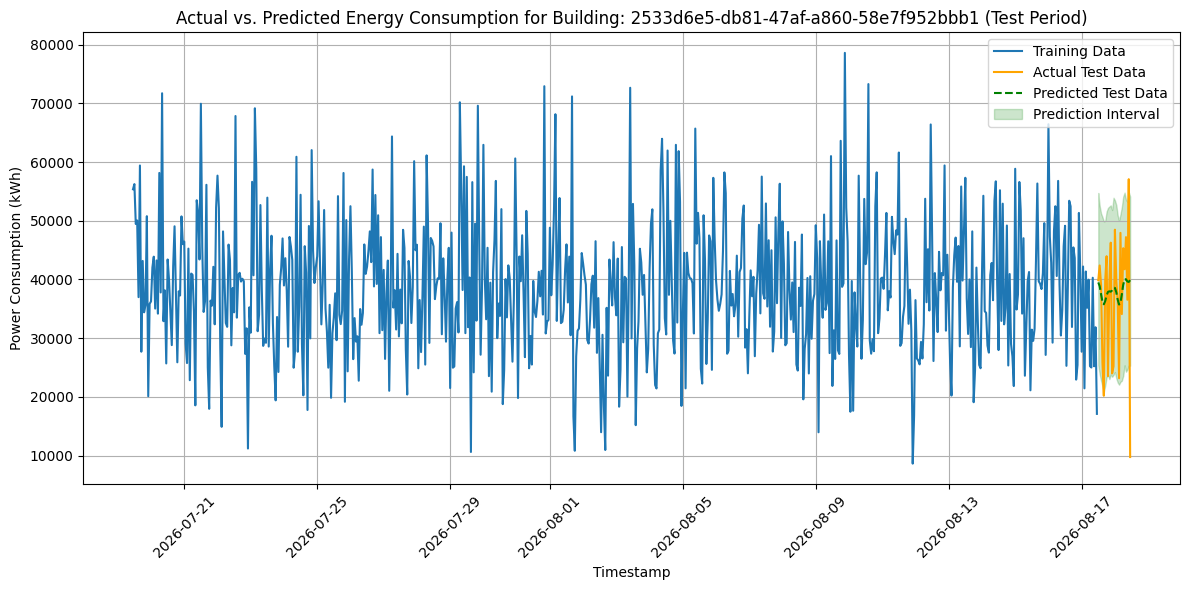


Processing building: 3209adf8-cde2-41d9-afd1-c7e2ffe6f130


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 9669.85, RMSE: 11967.23, MAPE: 31.43%


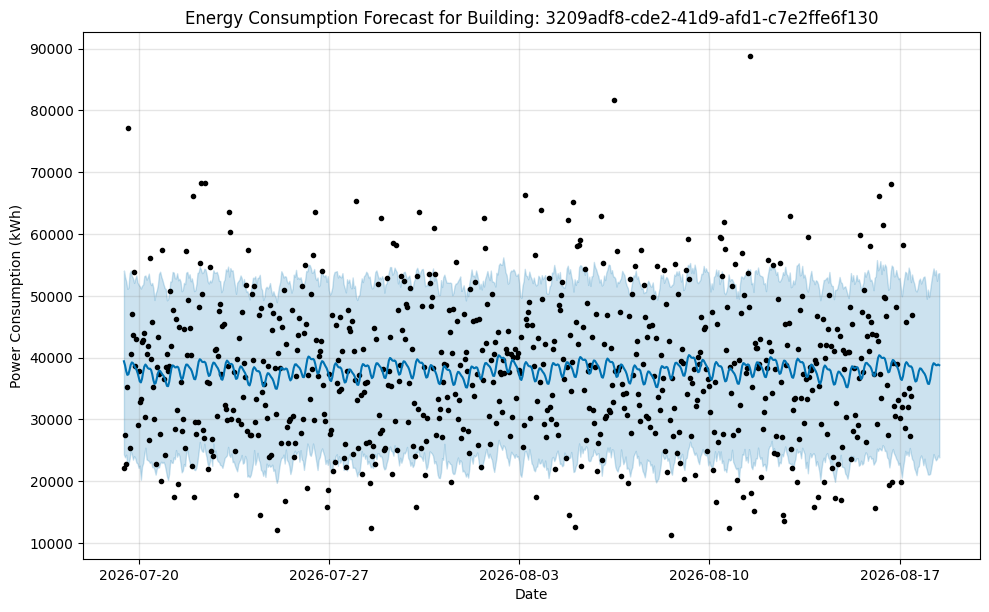

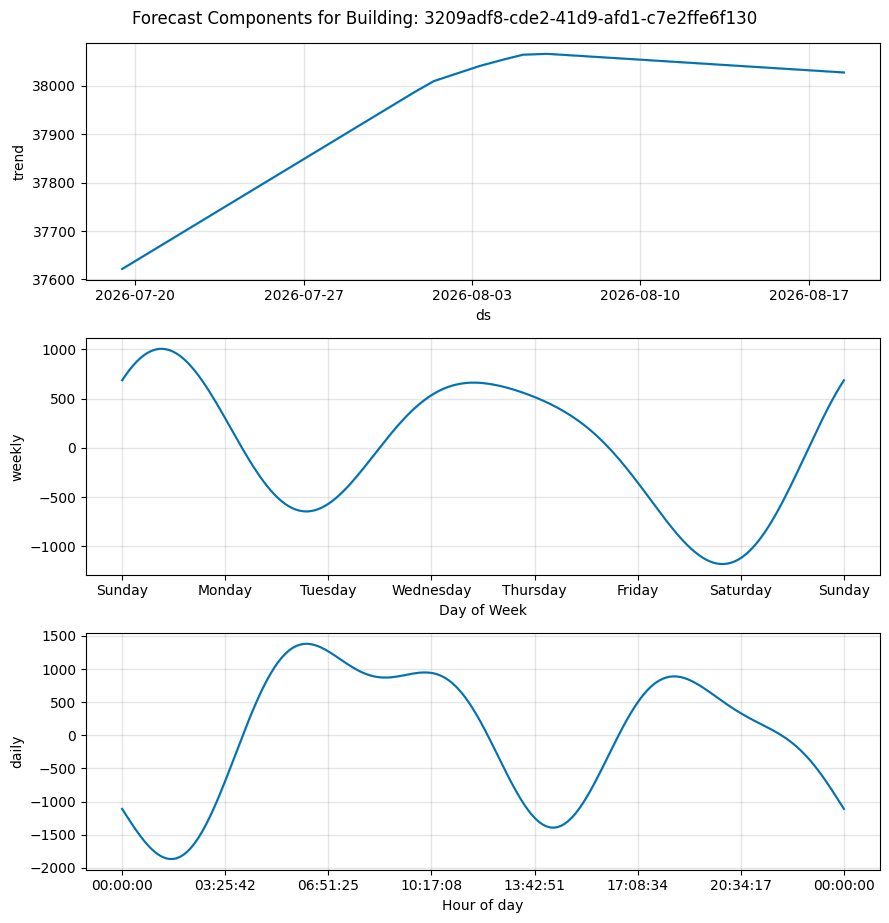

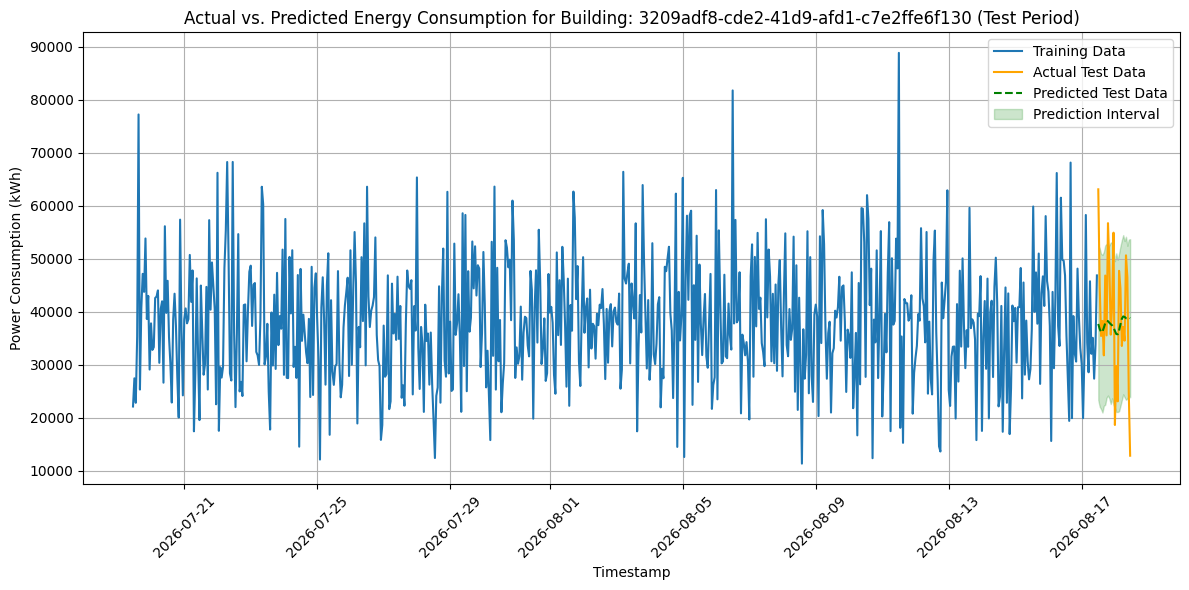


Processing building: 594db9a5-284d-4db0-9842-c5f0a23b0d3f


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 9734.89, RMSE: 12082.53, MAPE: 29.02%


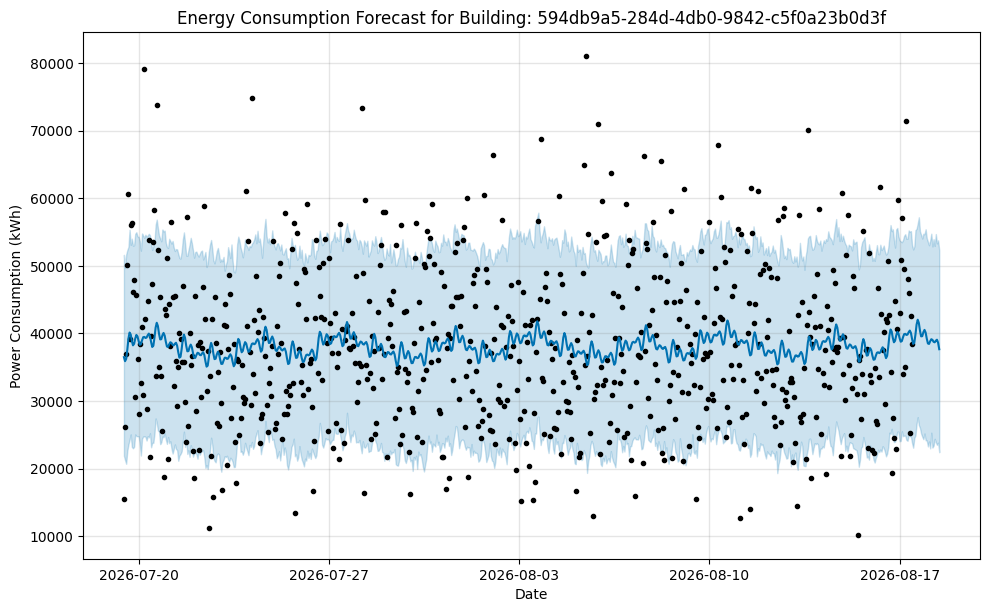

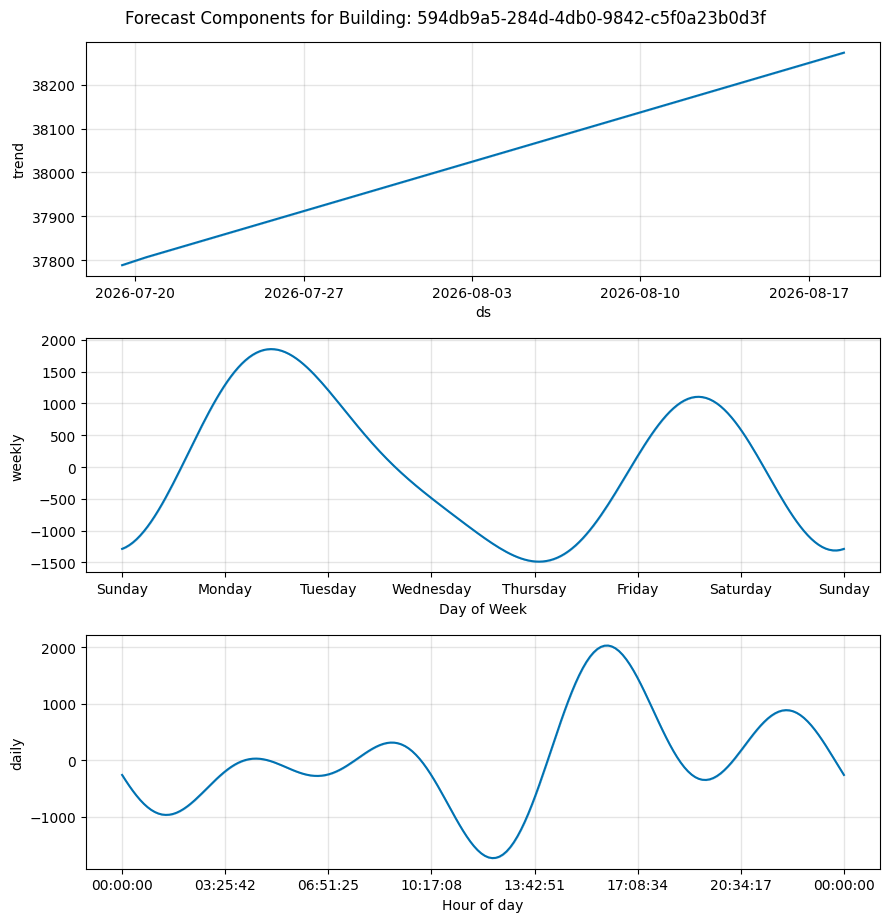

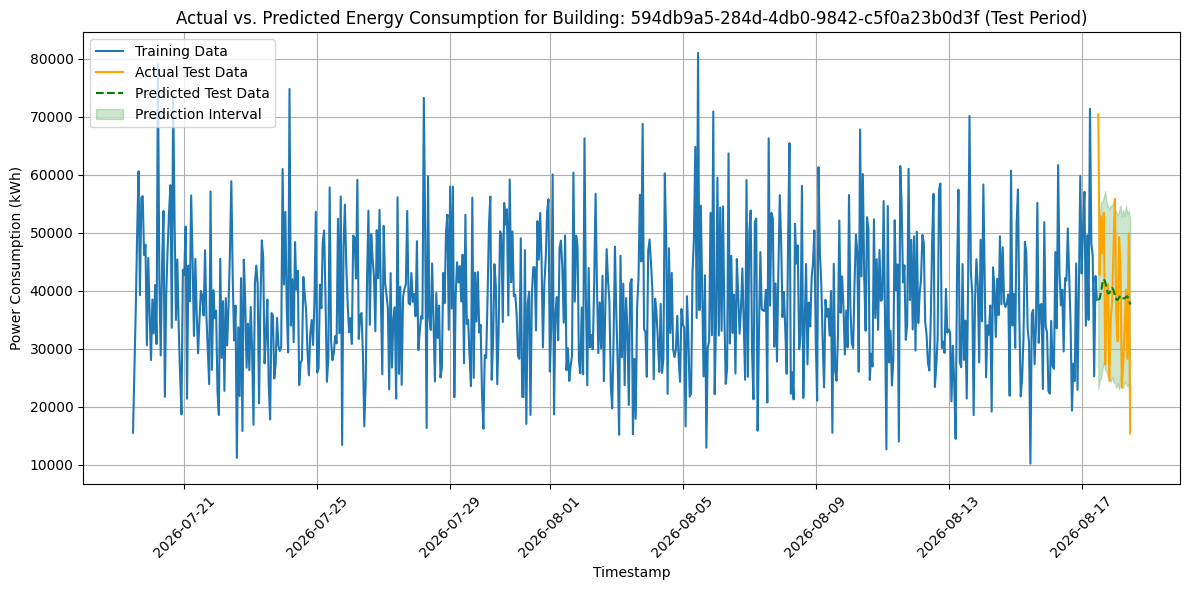


Processing building: 615b3026-9bed-49e1-b9ca-472151dd9abc


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 8712.15, RMSE: 11050.64, MAPE: 21.10%


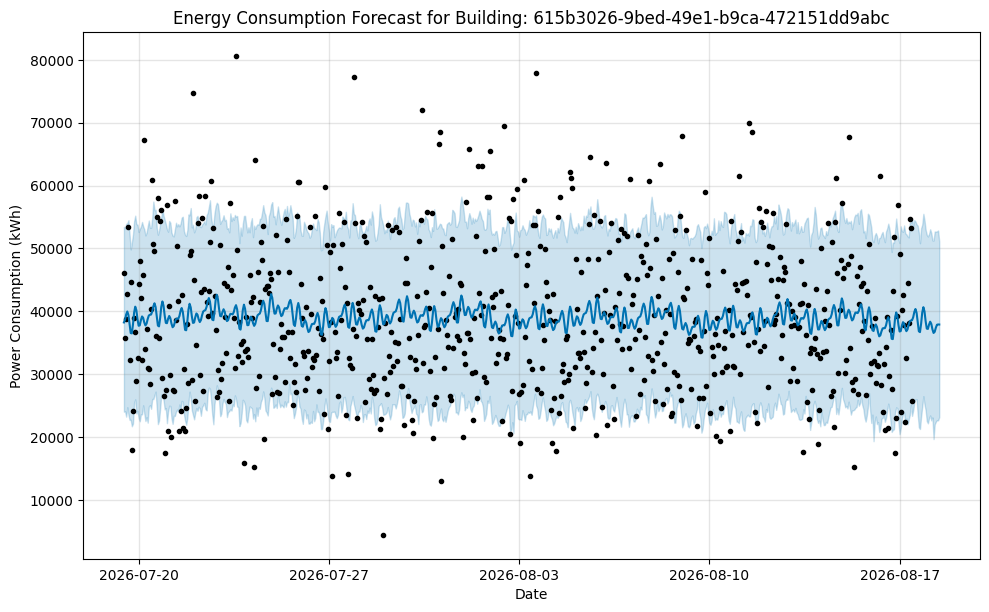

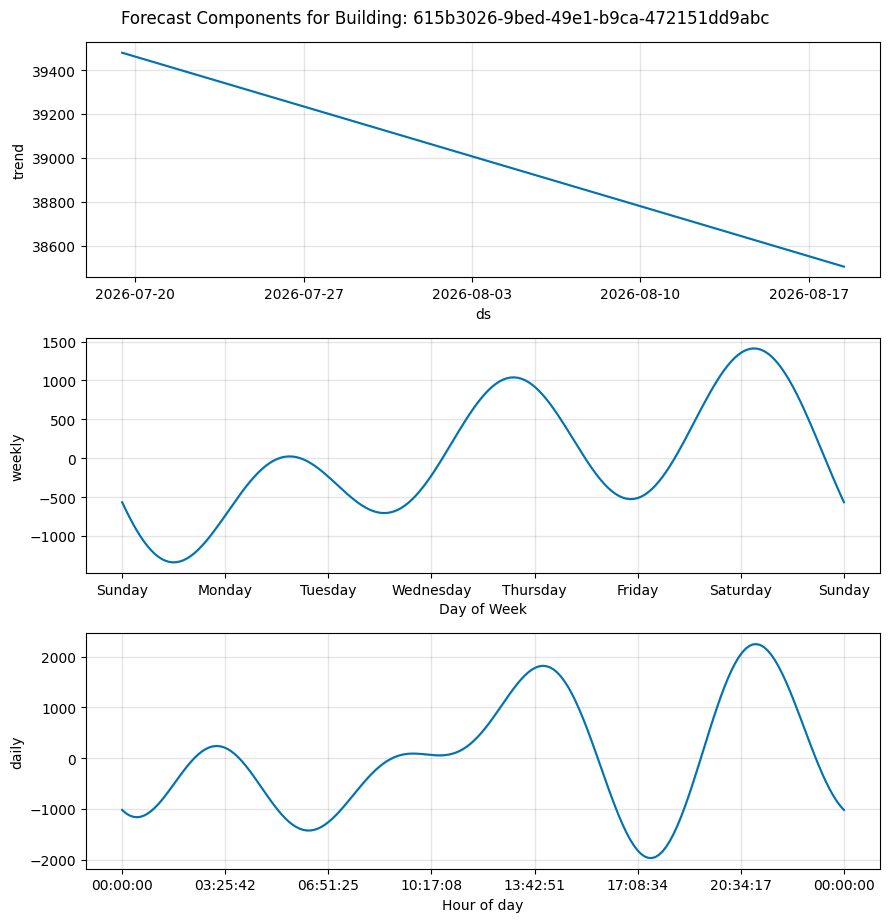

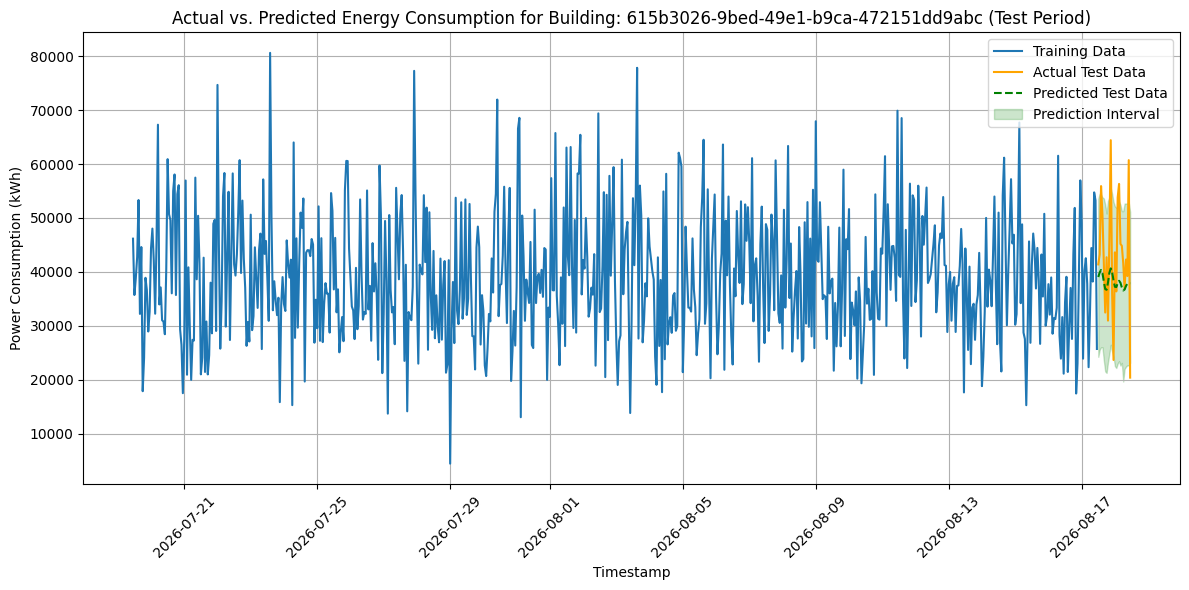


Processing building: 63b33efa-353b-4784-99cf-12b0a0b9685d


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 8934.35, RMSE: 11415.03, MAPE: 24.39%


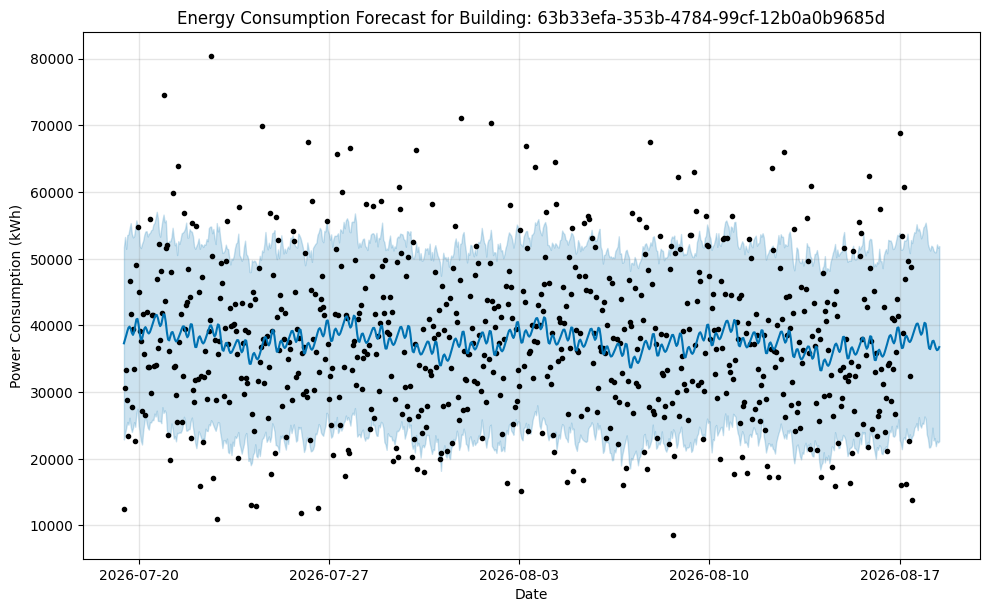

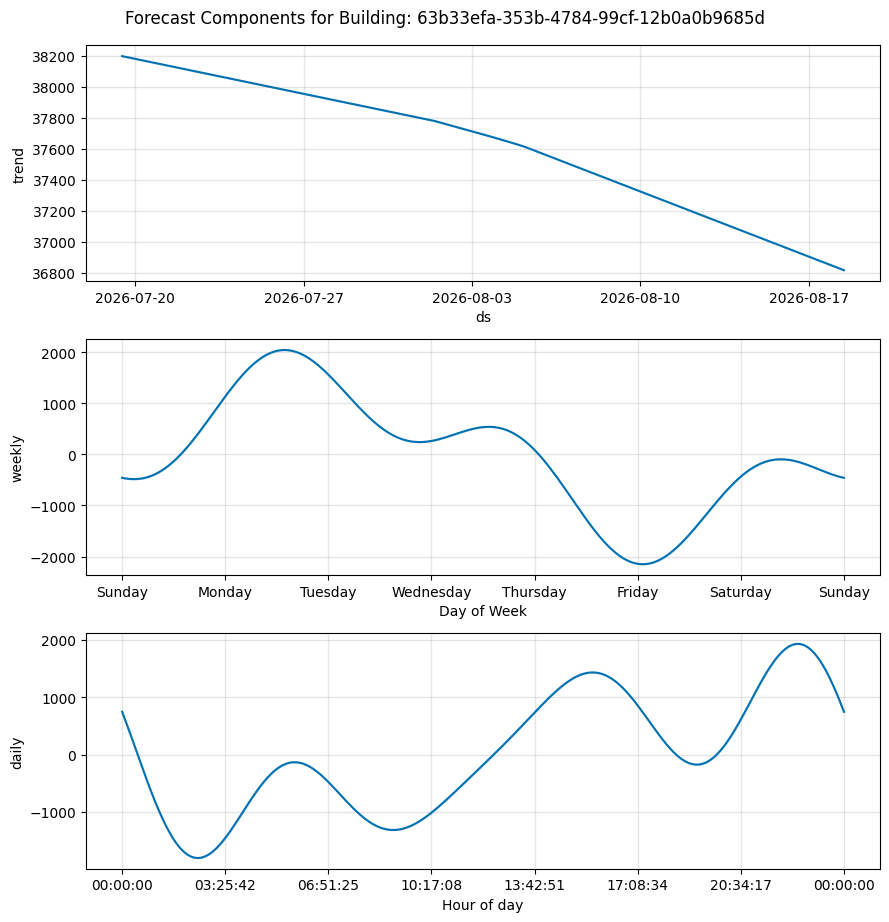

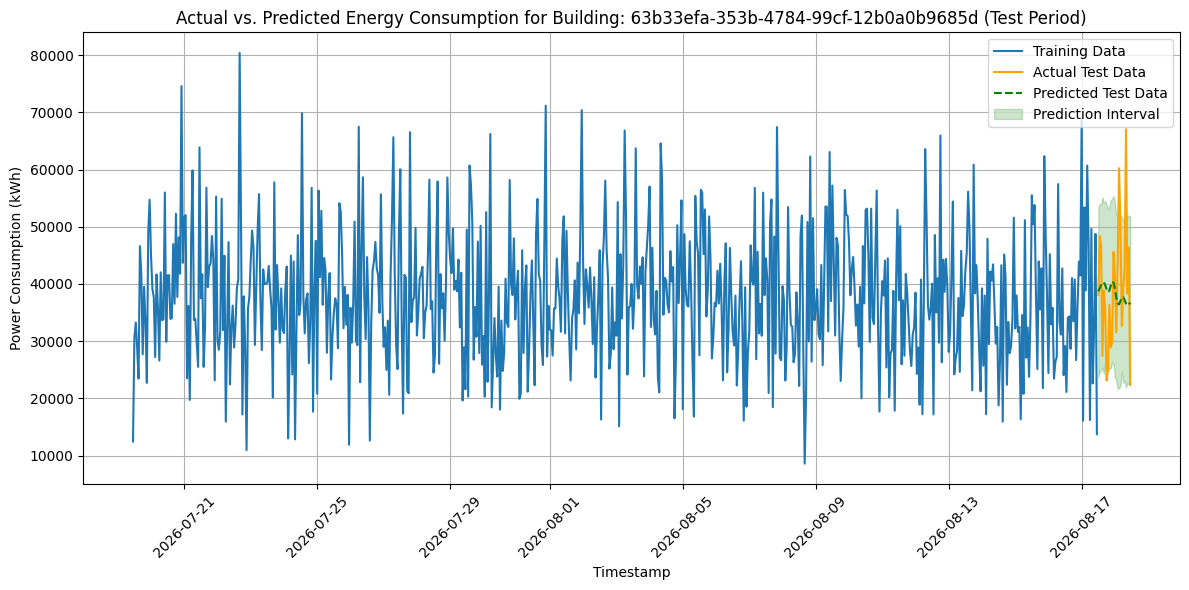


Processing building: 84645649-9bdf-4fe2-b270-9152fe7242f1


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 9697.17, RMSE: 11678.43, MAPE: 46.95%


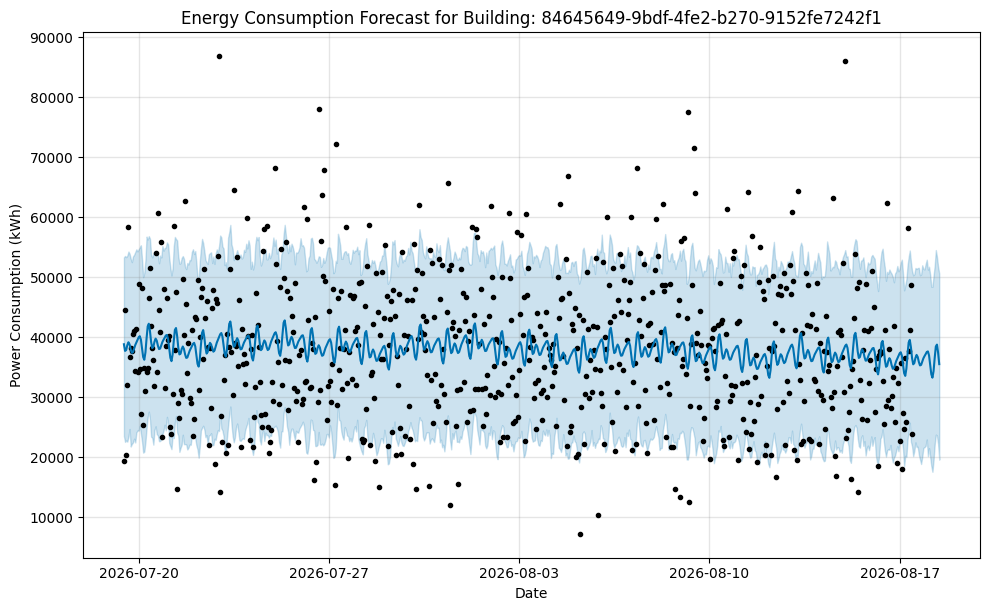

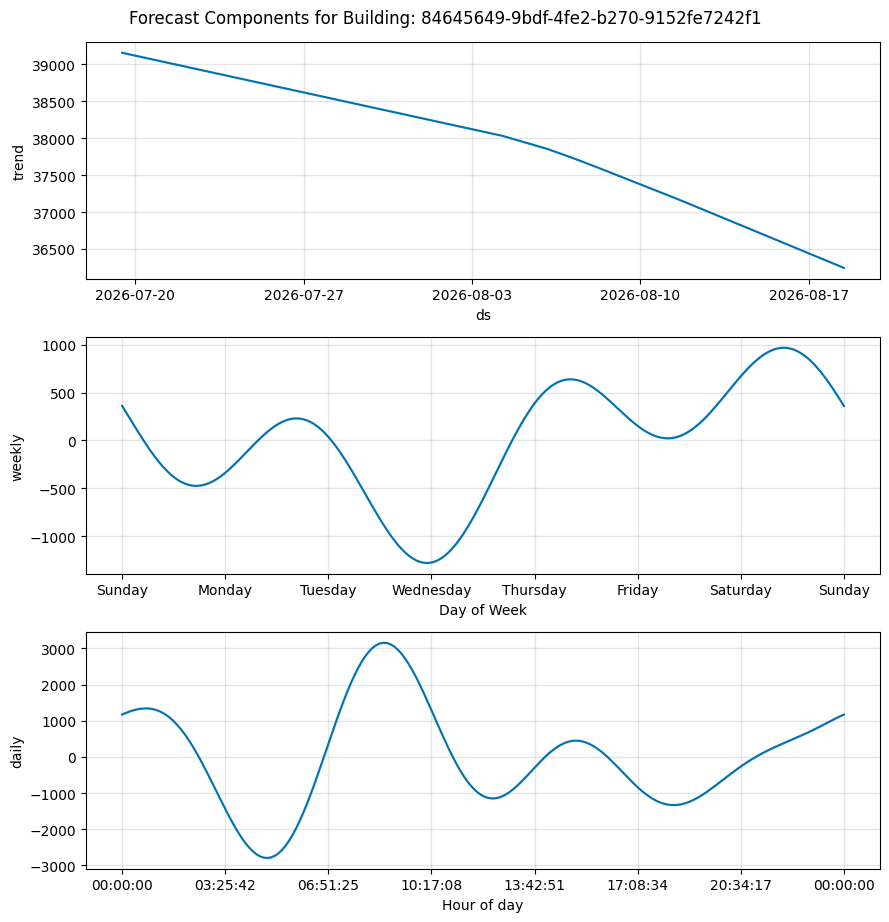

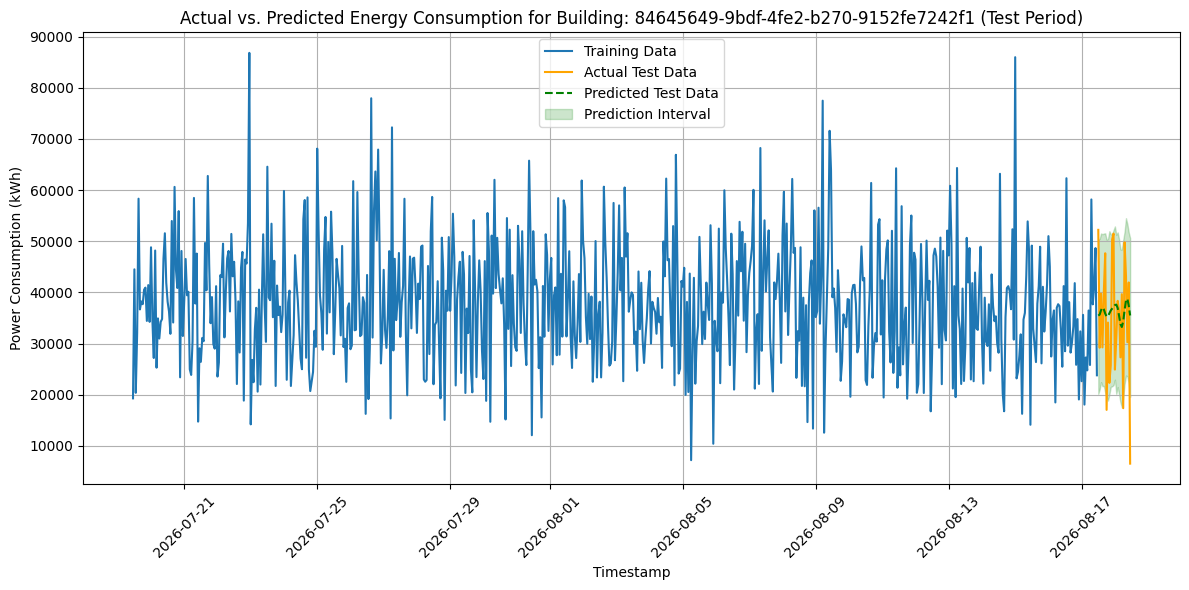


Processing building: a7eafc71-d8f5-41be-ac78-d8a24cbbea0c


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 9619.59, RMSE: 11833.60, MAPE: 27.15%


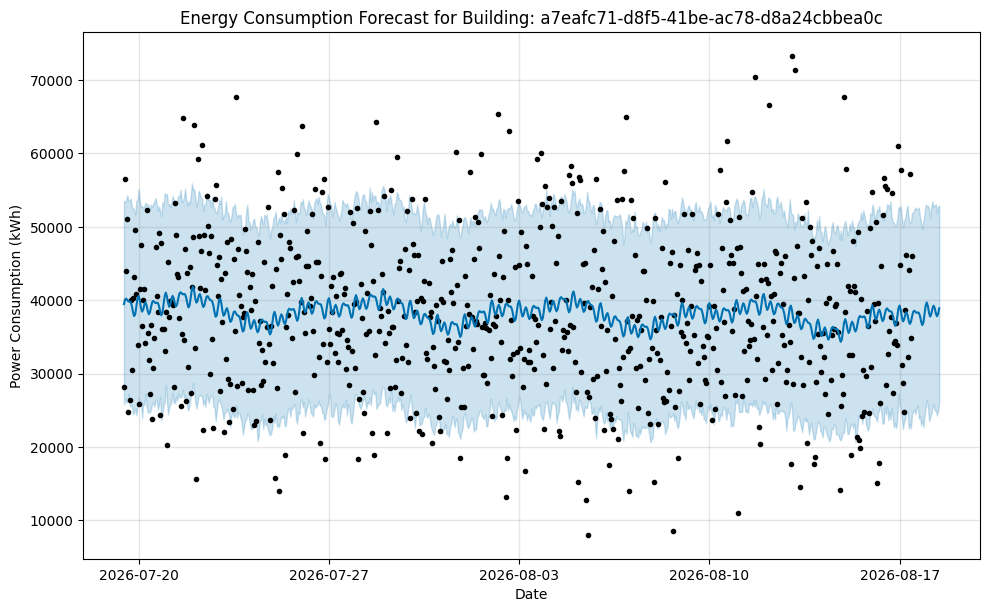

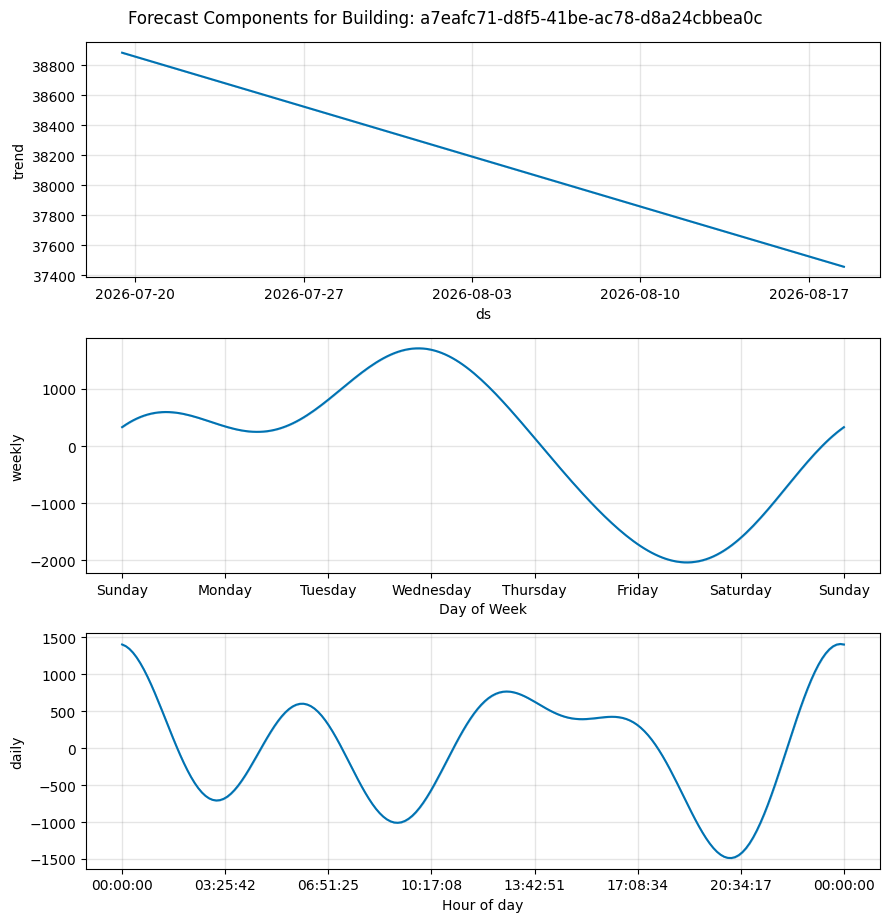

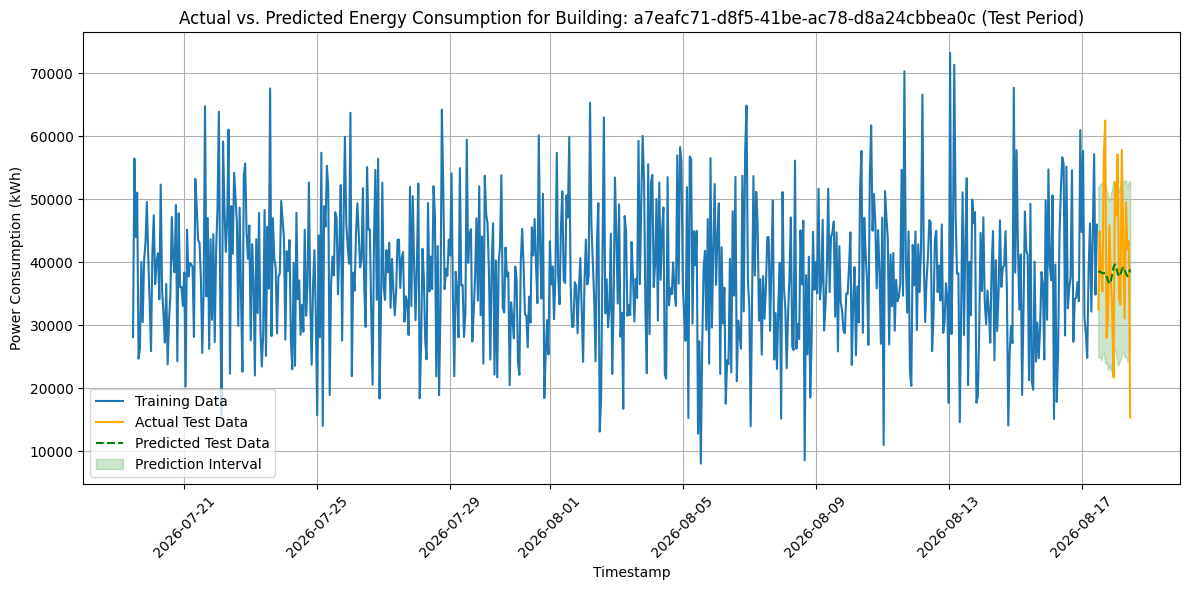


Processing building: ce2a4bc8-bbbd-44ca-aafe-dd57522b97f3


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 7513.17, RMSE: 10471.84, MAPE: 26.73%


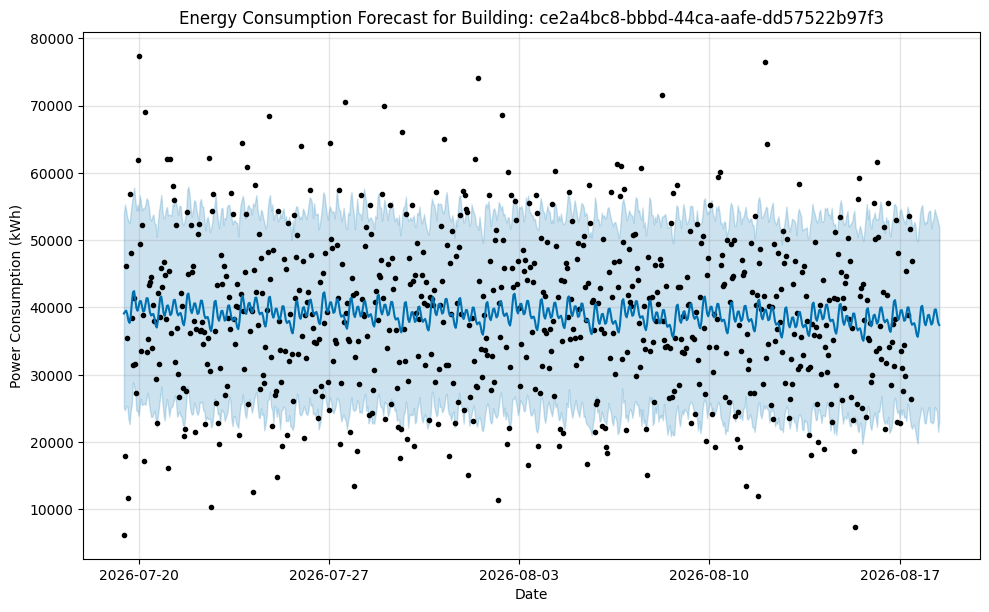

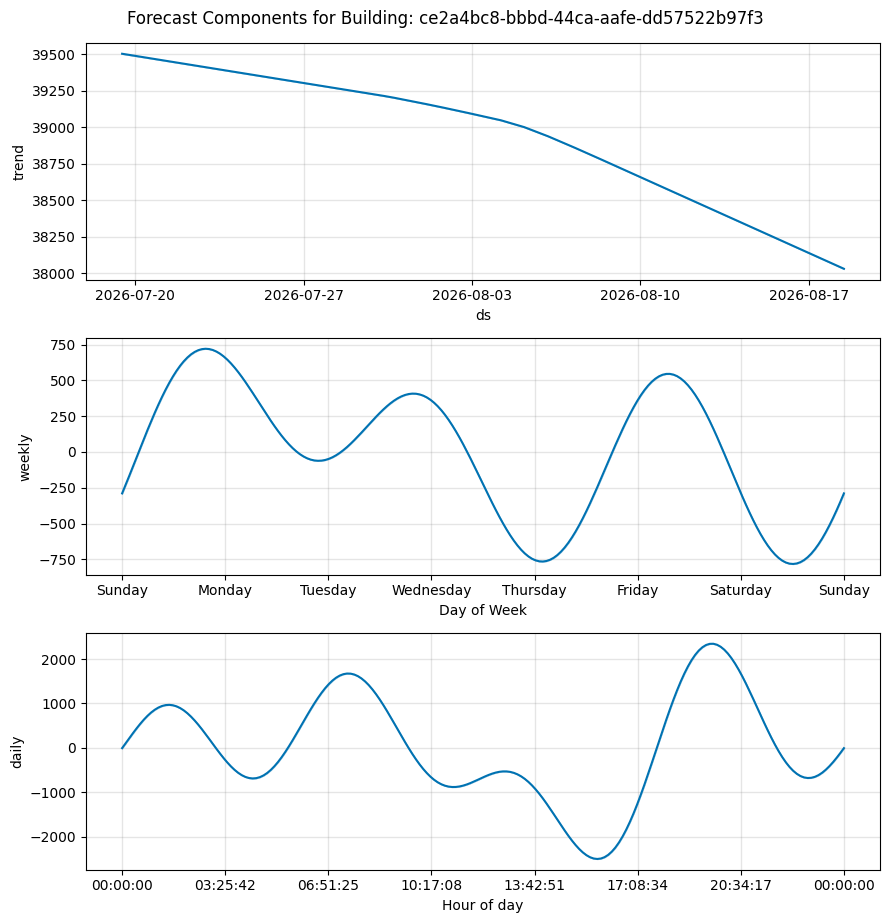

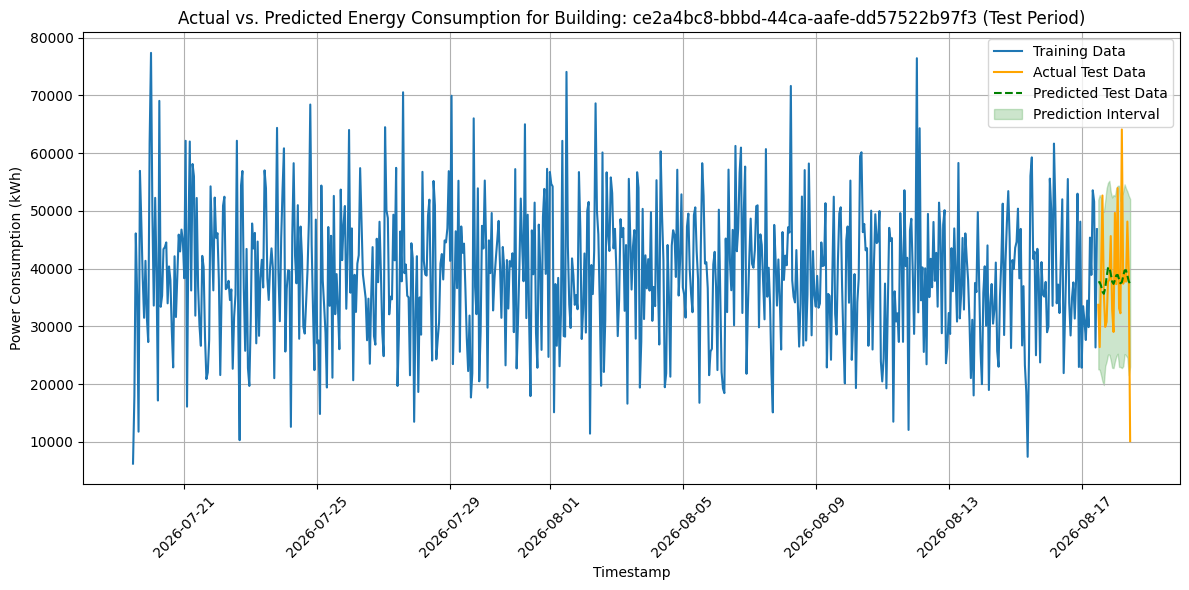


Processing building: e48909f1-2807-41b4-b2cb-c65430b92bd3


/tmp/ipykernel_483/2501826992.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


  MAE: 10059.01, RMSE: 13374.35, MAPE: 53.88%


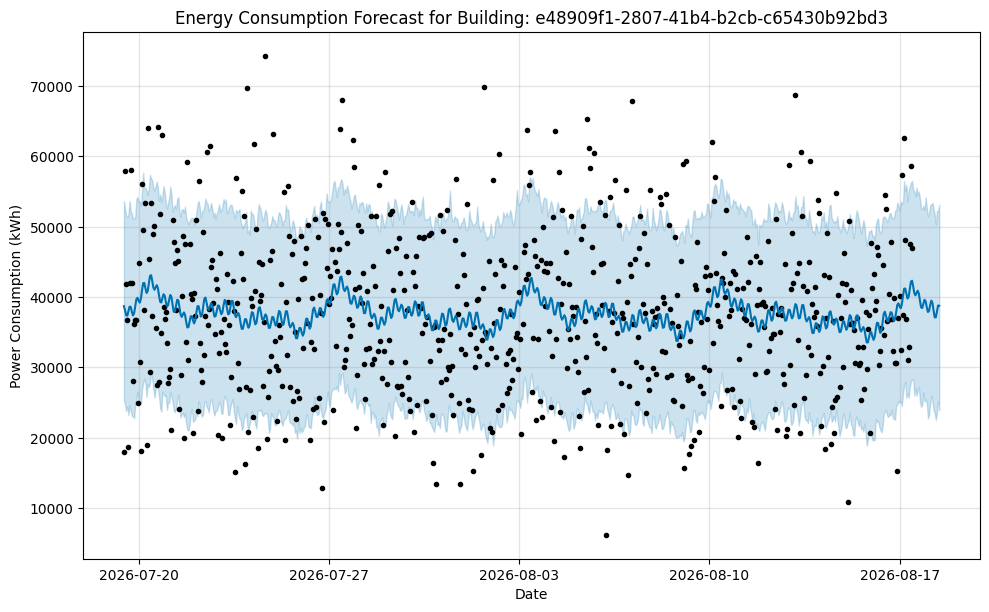

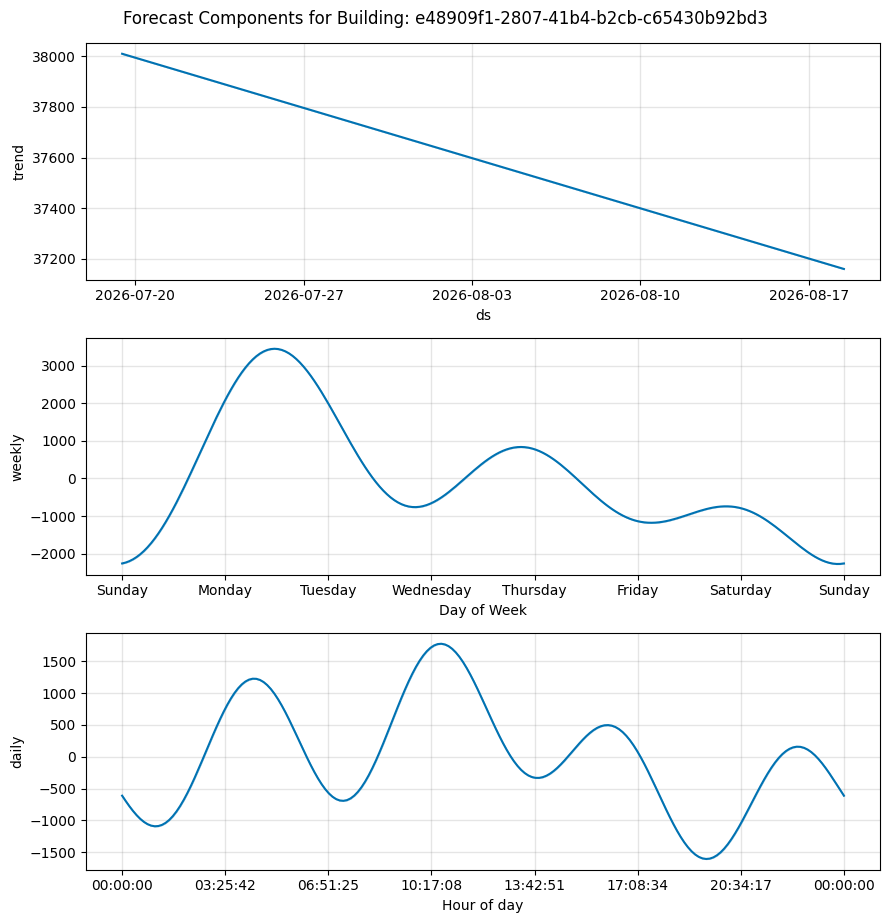

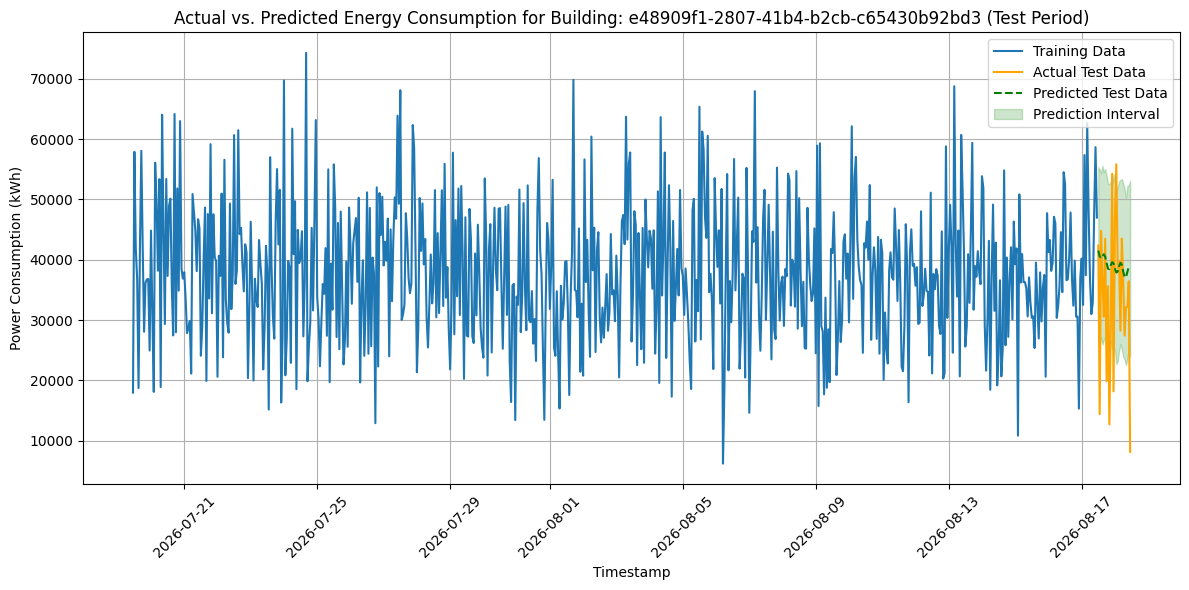


--- Summary of Forecasting Model Evaluations (per building) ---


,building_id,MAE,RMSE,MAPE
0,19646a91-383e-4f51-9a26-739401f89b39,10839.999213,13463.873031,32.876177
1,2533d6e5-db81-47af-a860-58e7f952bbb1,8293.951690,10812.550638,35.205291
2,3209adf8-cde2-41d9-afd1-c7e2ffe6f130,9669.853909,11967.226560,31.427081
3,594db9a5-284d-4db0-9842-c5f0a23b0d3f,9734.890908,12082.527250,29.022794
4,615b3026-9bed-49e1-b9ca-472151dd9abc,8712.148560,11050.638156,21.097759
5,63b33efa-353b-4784-99cf-12b0a0b9685d,8934.348542,11415.032150,24.390734
6,84645649-9bdf-4fe2-b270-9152fe7242f1,9697.168796,11678.433399,46.946760
7,a7eafc71-d8f5-41be-ac78-d8a24cbbea0c,9619.587307,11833.604485,27.145133
8,ce2a4bc8-bbbd-44ca-aafe-dd57522b97f3,7513.169623,10471.843880,26.729649
9,e48909f1-2807-41b4-b2cb-c65430b92bd3,10059.012674,13374.354476,53.881551



--- Key Insights from Forecasting ---
The Prophet model has been applied to forecast hourly energy consumption for each building. It captures daily and weekly seasonality patterns effectively.
The evaluation metrics (MAE, RMSE, MAPE) provide a quantitative measure of forecast accuracy for each building over the next 24 hours. MAPE is particularly useful for understanding prediction errors as a percentage of actual values.
Forecast plots visualize the predicted consumption alongside historical data and future trends. Component plots help in understanding the underlying daily and weekly patterns the model identified.
Buildings with higher MAE/RMSE values might require more sophisticated models or additional features for better prediction accuracy.


In [ ]:
# TASK 3: Develop a forecasting model to predict energy consumption
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Developing Energy Consumption Forecasting Model ---")

# Ensure 'timestamp' is datetime and sort the data
sensor_telemetry_df['timestamp'] = pd.to_datetime(sensor_telemetry_df['timestamp'])
sensor_telemetry_df = sensor_telemetry_df.sort_values(by=['building_id', 'timestamp'])

# Aggregate power consumption by building and hourly interval for forecasting
# We'll resample to hourly frequency and sum the power consumption
# Also, fill any missing hours with 0 or the last valid observation, depending on context.

# Create a list to store results for each building
all_building_forecasts = []
all_building_evaluations = []

unique_buildings = sensor_telemetry_df['building_id'].unique()

for building_id in unique_buildings:
    print(f"\nProcessing building: {building_id}")
    building_df = sensor_telemetry_df[sensor_telemetry_df['building_id'] == building_id].copy()

    # Prepare data for Prophet: resample to hourly, sum power consumption
    # Prophet expects columns named 'ds' (datestamp) and 'y' (series value)
    building_ts = building_df.set_index('timestamp')['power_consumption'].resample('H').sum().reset_index()
    building_ts = building_ts.rename(columns={'timestamp': 'ds', 'power_consumption': 'y'})

    # Fill any NaNs created by resampling (e.g., hours with no data) with 0
    building_ts['y'] = building_ts['y'].fillna(0)

    if len(building_ts) < 24 * 7: # Ensure enough data for meaningful forecasting (e.g., at least a week)
        print(f"Skipping building {building_id} due to insufficient data for forecasting (less than 7 days hourly data).")
        continue

    # Split data into training and testing sets
    # Use the last 24 hours (1 day) for testing, remaining for training
    train_size = int(len(building_ts) - 24)
    train_df = building_ts.iloc[:train_size]
    test_df = building_ts.iloc[train_size:]

    # Initialize and fit Prophet model
    model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False) # Assuming daily and weekly patterns
    model.fit(train_df)

    # Create future dataframe for forecasting (next 24 hours)
    future = model.make_future_dataframe(periods=24, freq='H', include_history=True)

    # Make predictions
    forecast = model.predict(future)

    # Extract the last 24 hours of the forecast for evaluation
    forecast_24h = forecast.iloc[-24:].copy()

    # Merge actual test data with forecast for evaluation
    eval_df = pd.merge(test_df, forecast_24h[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

    # Ensure 'y' column from test_df is aligned with forecast
    actual_y = eval_df['y']
    predicted_y = eval_df['yhat']

    # Evaluate the model
    mae = mean_absolute_error(actual_y, predicted_y)
    rmse = np.sqrt(mean_squared_error(actual_y, predicted_y))
    mape = np.mean(np.abs((actual_y - predicted_y) / actual_y)) * 100 if np.mean(actual_y) != 0 else np.nan

    print(f"  MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

    all_building_evaluations.append({
        'building_id': building_id,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    })

    # Store forecast data for plots
    all_building_forecasts.append({
        'building_id': building_id,
        'forecast_df': forecast.tail(24) # Only store the actual 24-hour forecast
    })

    # Plot forecast for the current building
    fig = model.plot(forecast)
    plt.title(f'Energy Consumption Forecast for Building: {building_id}')
    plt.xlabel('Date')
    plt.ylabel('Power Consumption (kWh)')
    plt.show()

    fig = model.plot_components(forecast)
    plt.suptitle(f'Forecast Components for Building: {building_id}', y=1.02) # Adjust suptitle position
    plt.show()

    # Plot actual vs. predicted for the test period
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Training Data')
    plt.plot(test_df['ds'], test_df['y'], label='Actual Test Data', color='orange')
    plt.plot(forecast_24h['ds'], forecast_24h['yhat'], label='Predicted Test Data', color='green', linestyle='--')
    plt.fill_between(forecast_24h['ds'], forecast_24h['yhat_lower'], forecast_24h['yhat_upper'], color='green', alpha=0.2, label='Prediction Interval')
    plt.title(f'Actual vs. Predicted Energy Consumption for Building: {building_id} (Test Period)')
    plt.xlabel('Timestamp')
    plt.ylabel('Power Consumption (kWh)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


print("\n--- Summary of Forecasting Model Evaluations (per building) ---")
eval_summary_df = pd.DataFrame(all_building_evaluations)
display(eval_summary_df)

print("\n--- Key Insights from Forecasting ---")
print("The Prophet model has been applied to forecast hourly energy consumption for each building. It captures daily and weekly seasonality patterns effectively.")
print("The evaluation metrics (MAE, RMSE, MAPE) provide a quantitative measure of forecast accuracy for each building over the next 24 hours. MAPE is particularly useful for understanding prediction errors as a percentage of actual values.")
print("Forecast plots visualize the predicted consumption alongside historical data and future trends. Component plots help in understanding the underlying daily and weekly patterns the model identified.")
print("Buildings with higher MAE/RMSE values might require more sophisticated models or additional features for better prediction accuracy.")

# TASK 3
